-------- INITIAL PARAMETERS --------
d_wire / d :                        0.4
Beam diameter at CRL3 :             650 µm
Beam diameter at CRL4a :            180 µm
Distance between CRL4a and TCC :    1.40 m
Distance between CRL4a and O1 :     6.00 m
Distance between TCC and Detector : 7.00 m
Position of O2:                     7.700 m
Diameter of O2:                     50.00 µm
-------- CALCULATED PARAMETERS --------
Focal length of CRL3:               10.511 m
Focal length of CRL4a:              2.697 m
O1 image position (from CRL4a):     4.901 m
Magnification (CRL4a):              0.817
Diameter of O1:                     220.42 µm
Diameter of image of O1:            180.04 µm
Position of CRL4b:                  12.801 m
Focal length of CRL4b:              1.737 m
Magnification (CRL4b):              0.842
Distance between TCC and image of O2: 6.435 m
Diameter of image of O2:            25.82 µm
d/2f (CRL4a→TCC):                   64.29 µrad
Convergence angle before detector :   76.37

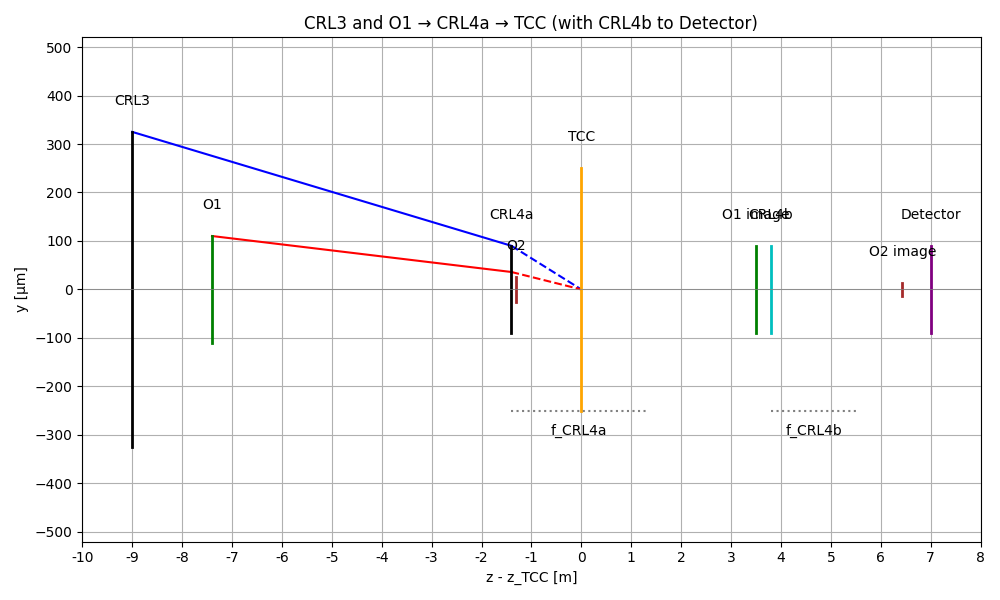

In [1]:
########################## RAY OPTICS CALCULATIONS OF DF SETUP PARAMETERS ###################
# Distances are absolute (no "-" sign here).

import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

# ---------------- Parameters ----------------
D_crl3 = 650e-6   # beam diameter at CRL3 [m]
D_crl4a = 180e-6  # beam diameter at CRL4a [m]

X1 = 9.0   # distance between TCC and CRL3 [m]
X2 = 1.4   # distance between CRL4a and TCC [m]
X3 = 6.0   # distance between CRL4a and O1 [m]
X9 = 7.0   # distance between TCC and detector [m]

d_wire_over_d = 0.4  # Ratio of the beam to wire diameter

# ---------------- Core geometry & lensing ----------------
d_wire = D_crl4a * d_wire_over_d

# Focal length CRL4a (from your original relation)
f_crl4a = np.abs(D_crl4a / (((D_crl3 - D_crl4a) / (X1 - X2)) - D_crl4a / X2))

# O1 image distance from CRL4a
X4 = 1.0 / (1.0 / f_crl4a - 1.0 / X3)
Magnification = X4 / X3

# Ray angle at CRL4a from O1 that ends at TCC
theta1_in = (d_wire / 2.0) * (1.0 / X2 - 1.0 / f_crl4a)

# O1 size and its image through CRL4a
Diam_O1 = 2.0 * (d_wire / 2.0 + theta1_in * X3)
Diam_img_O1 = Diam_O1 * Magnification

# Focal length of CRL3 (from your relation)
f_crl3 = (X1 - X2) / (1.0 - D_crl4a / D_crl3)

# ---------------- CRL4b (after O1 image) ----------------
X5 = 0.3   # Distance between O1 image and CRL4b [m]
z_crl3 = 0.0
z_crl4a = X1 - X2
z_tcc = X1
z_O1 = z_crl4a - X3
z_O1_img = z_crl4a + X4

z_crl4b = z_O1_img + X5               # Absolute position of CRL4b
z_detector = X1 + X9                   # Absolute position of detector

# Image TCC -> detector with CRL4b
d_obj = z_crl4b - z_tcc
d_img = z_detector - z_crl4b
f_crl4b = 1.0 / (1.0 / d_obj + 1.0 / d_img)
magnification_crl4b = d_img / d_obj

# ---------------- O2 (kept from your version) ----------------
Diam_O2 = 50e-6  # 50 µm
z_O2 = z_crl4a + 0.1  # 10 cm after CRL4a

d_O2_obj = z_crl4b - z_O2
d_O2_img = 1.0 / (1.0 / f_crl4b - 1.0 / d_O2_obj)
z_O2_img = z_crl4b + d_O2_img
Magnif_O2 = d_O2_img / d_O2_obj
Diam_img_O2 = Diam_O2 * Magnif_O2

# ---------------- Convergence angle before detector ----------------
# Use the blue-ray slope just before TCC (segment CRL4a->TCC), then extend to CRL4b:
# slope_out magnitude = (D_crl4a/2) / X2  ; height at CRL4b = slope * (z_crl4b - z_tcc)
# convergence angle (half-angle) from CRL4b to detector = y_L / (z_detector - z_crl4b)
slope_out_mag = (D_crl4a / 2.0) / X2
y_at_crl4b = slope_out_mag * (z_crl4b - z_tcc)
conv_angle = y_at_crl4b / (z_detector - z_crl4b)           # [rad]
conv_angle_urad = conv_angle * 1e6                          # [µrad]

# ---------------- Beam edges (for plotting) ----------------
y_crl3 = D_crl3 / 2.0
y_crl4a = D_crl4a / 2.0
y_o1 = Diam_O1 / 2.0
y_wire = d_wire / 2.0

# ---------------- Prints ----------------
print("-------- INITIAL PARAMETERS --------")
print(f"d_wire / d :                        {d_wire_over_d:.1f}")
print(f"Beam diameter at CRL3 :             {D_crl3*1e6:.0f} µm")
print(f"Beam diameter at CRL4a :            {D_crl4a*1e6:.0f} µm")
print(f"Distance between CRL4a and TCC :    {X2:.2f} m")
print(f"Distance between CRL4a and O1 :     {X3:.2f} m")
print(f"Distance between TCC and Detector : {X9:.2f} m")
print(f"Position of O2:                     {z_O2:.3f} m")
print(f"Diameter of O2:                     {Diam_O2*1e6:.2f} µm")

print("-------- CALCULATED PARAMETERS --------")
print(f"Focal length of CRL3:               {f_crl3:.3f} m")
print(f"Focal length of CRL4a:              {f_crl4a:.3f} m")
print(f"O1 image position (from CRL4a):     {X4:.3f} m")
print(f"Magnification (CRL4a):              {Magnification:.3f}")
print(f"Diameter of O1:                     {Diam_O1*1e6:.2f} µm")
print(f"Diameter of image of O1:            {Diam_img_O1*1e6:.2f} µm")
print(f"Position of CRL4b:                  {z_crl4b:.3f} m")
print(f"Focal length of CRL4b:              {f_crl4b:.3f} m")
print(f"Magnification (CRL4b):              {magnification_crl4b:.3f}")
print(f"Distance between TCC and image of O2: {z_O2_img - z_tcc:.3f} m")
print(f"Diameter of image of O2:            {Diam_img_O2*1e6:.2f} µm")
print(f"d/2f (CRL4a→TCC):                   {(D_crl4a/(2*X2))*1e6:.2f} µrad")
print(f"Convergence angle before detector : {conv_angle_urad:7.2f} µrad")
print("--------------------------")

################ RAY TRACING OF THE PARAMETERS ABOVE ############

fig, ax = plt.subplots(figsize=(10, 6))
f_line_y = -250  # µm, for focal length line display

# ---------- BLUE RAY: from CRL3 to TCC ----------
# Segment CRL3 -> CRL4a
z_vals1 = [z_crl3, z_crl4a]
y_vals1 = [y_crl3 * 1e6, y_crl4a * 1e6]
# Segment CRL4a -> TCC
z_vals2 = [z_crl4a, z_tcc]
y_vals2 = [y_crl4a * 1e6, 0.0]

ax.plot(z_vals1, y_vals1, 'b')
ax.plot(z_vals2, y_vals2, 'b--')

# ---------- RED RAY: from O1 to TCC ----------
z_vals3 = [z_O1, z_crl4a]
y_vals3 = [y_o1 * 1e6, y_wire * 1e6]
z_vals4 = [z_crl4a, z_tcc]
y_vals4 = [y_wire * 1e6, 0.0]

ax.plot(z_vals3, y_vals3, 'r')
ax.plot(z_vals4, y_vals4, 'r--')

# ---------- Optical elements ----------
def draw_aperture(z, D, label, color='k'):
    ax.plot([z, z], [-D/2 * 1e6, D/2 * 1e6], color=color, lw=2)
    ax.text(z, D/2 * 1e6 + 50, label, ha='center', va='bottom', fontsize=10)

draw_aperture(z_crl3, D_crl3, 'CRL3')
draw_aperture(z_crl4a, D_crl4a, 'CRL4a')
draw_aperture(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_aperture(z_O1, Diam_O1, 'O1', 'g')
draw_aperture(z_O1_img, Diam_img_O1, 'O1 image', 'g')
draw_aperture(z_crl4b, D_crl4a, 'CRL4b', 'c')
draw_aperture(z_detector, D_crl4a, 'Detector', 'purple')
draw_aperture(z_O2, Diam_O2, 'O2', 'brown')
draw_aperture(z_O2_img, Diam_img_O2, 'O2 image', 'brown')

# ---------- Focal lengths ----------
ax.hlines(f_line_y, z_crl4a, z_crl4a + f_crl4a, colors='gray', linestyles='dotted')
ax.text(z_crl4a + f_crl4a/2, f_line_y - 50, 'f_CRL4a', ha='center', fontsize=10)

ax.hlines(f_line_y, z_crl4b, z_crl4b + f_crl4b, colors='gray', linestyles='dotted')
ax.text(z_crl4b + f_crl4b/2, f_line_y - 50, 'f_CRL4b', ha='center', fontsize=10)

# ---------- Shift x-axis labels so that TCC appears at 0 & set ticks ----------
offset = z_tcc
# choose dynamic limits covering up to the farther of O1 image or detector
x_min = -1
x_max = int(np.ceil(max(z_O1_img, z_detector) + 1))
ax.set_xlim(x_min, x_max)

xticks = np.arange(x_min, x_max + 1, 1)   # every 1 m (absolute z)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{tick - offset:.0f}" for tick in xticks])
ax.set_xlabel("z - z_TCC [m]")

# ---------- y-ticks every 100 µm ----------
yticks = np.arange(-500, 500 + 1, 100)
ax.set_yticks(yticks)
ax.set_ylabel("y [µm]")

# ---------- Formatting ----------
ax.axhline(0, color='gray', lw=0.5)
ax.set_title("CRL3 and O1 → CRL4a → TCC (with CRL4b to Detector)")
ax.set_ylim(-520, 520)
ax.grid(True)
plt.tight_layout()
plt.show()


-------- INPUTS --------
CRL3 at z = -9.00 m,  R=2.000e-04 m, N=1, f1=10.512 m
CRL4a at z = -1.215 m, R=1.250e-04 m, N=3, f2=2.190 m
O1 at z = -7.21 m, diameter = 222.0 µm
O1 image by CRL4a at z = 2.234 m, diameter = 127.6 µm
CRL4b at z = 2.434 m (O1 image + 0.20 m), R=1.250e-04 m, N=4, f3=1.642 m
Detector at z = 7.50 m

-------- RESULTS --------
Half Angle just after CRL3 (outer ray, toward CRL4a):    30.92 µrad
Half Angle just after CRL4a (outer ray):    69.41 µrad
Half Angle just after CRL4b (outer ray):    33.46 µrad
d_w/d at CRL4a (height_O1edge / height_outer) = 0.412
Blue-ray focus after CRL4a is at z = -0.000457 m → distance to TCC: -0.46 mm
Blue-ray focus after CRL4b is at z = 7.483645 m → distance to detector: +16.36 mm


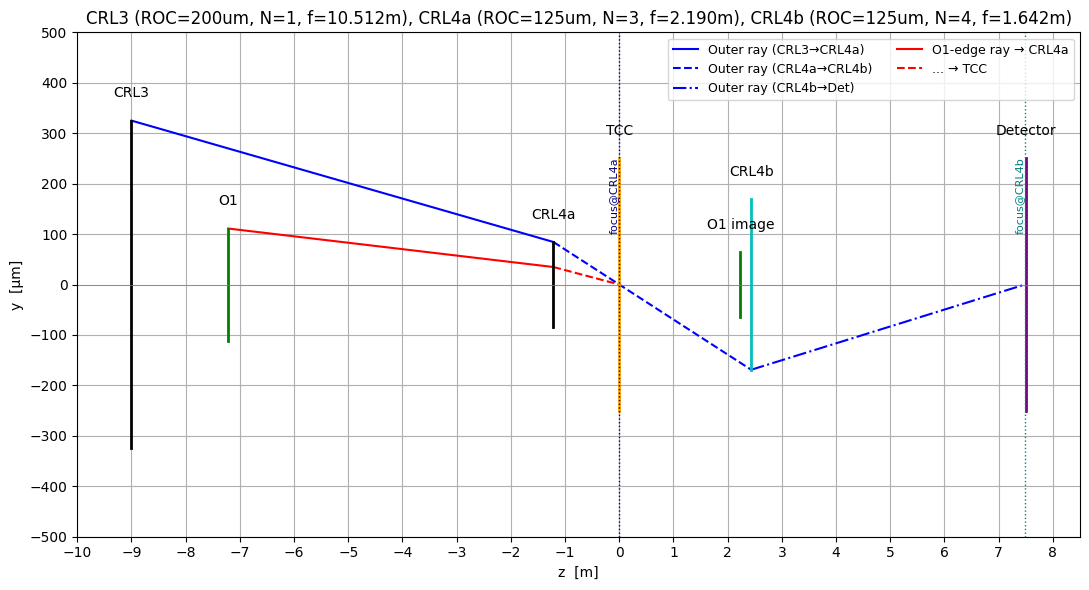

In [1]:
# Ray sketcher for CRL3 → CRL4a → (TCC) → CRL4b → Detector
# Uses thin-lens (ABCD) ray tracing with simple (y, theta) state.

import numpy as np
import matplotlib.pyplot as plt

# ----------------- Inputs (EDIT HERE) -----------------
delta = 9.513092e-6   # diamond at 8766 eV (fixed)

# Beam at CRL3 (parallel rays):
D_crl3 = 650e-6       # beam diameter at CRL3 [m]

# CRL3 (position is fixed at -9 m from TCC):
z_crl3 = -9.0         # [m]
R1, N1 = 200e-6, 1    # ROC [m], number of elements

# CRL4a:
z_crl4a = -1.215       # absolute position [m] (TCC at z=0)
R2, N2  = 125e-6, 3   # ROC [m], number of elements

# CRL4b (position will be set to image(O1 by CRL4a) + 0.20 m)
R3, N3  = 125e-6, 4   # ROC [m], number of elements

# Object O1 (size & position):
Diam_O1 = 222e-6      # [m]
z_O1    = z_crl4a - 6.0  # e.g. 6 m upstream of CRL4a

# Detector:
z_det   = 7.5         # [m]

# ----------------- Helpers -----------------
def f_from_R_N(R, N, delta):
    return R / (2.0 * N * delta)

def free_space(y, th, L):
    return y + L * th, th

def thin_lens(y, th, f):
    return y, th - y / f

# ----------------- Focal lengths -----------------
f1 = f_from_R_N(R1, N1, delta)  # CRL3
f2 = f_from_R_N(R2, N2, delta)  # CRL4a
f3 = f_from_R_N(R3, N3, delta)  # CRL4b

# ----------------- Geometry: O1 image by CRL4a → CRL4b position -----------------
s_o  = z_crl4a - z_O1                          # (>0 if O1 is left of CRL4a)
s_i  = 1.0 / (1.0 / f2 - 1.0 / s_o)
z_O1_img = z_crl4a + s_i
z_crl4b  = z_O1_img + 0.20                     # CRL4b is 20 cm after O1 image

# Magnification & image diameter of O1 (by CRL4a)
M_O1 = s_i / s_o
Diam_O1_img = abs(M_O1) * Diam_O1

# ----------------- TCC -----------------
z_tcc = 0.0

# ----------------- Ray 1: "outer ray" from CRL3 -----------------
y, th = D_crl3 / 2.0, 0.0          # start at top edge, parallel

# CRL3 → CRL4a
y, th = thin_lens(y, th, f1)
y, th = free_space(y, th, z_crl4a - z_crl3)
y_outer_at_crl4a = y

# CRL4a
y, th = thin_lens(y, th, f2)
theta_after_crl4a = th

# Focus of BLUE ray after CRL4a (may be before or after TCC)
if abs(theta_after_crl4a) > 0:
    z_focus_after_crl4a = z_crl4a - y_outer_at_crl4a / theta_after_crl4a
else:
    z_focus_after_crl4a = np.nan  # collimated

# CRL4a → CRL4b
y_before_crl4b, th_before_crl4b = free_space(y, th, z_crl4b - z_crl4a)

# CRL4b
y2, th2 = thin_lens(y_before_crl4b, th_before_crl4b, f3)
theta_after_crl4b = th2

# Focus of BLUE ray after CRL4b (near detector)
if abs(theta_after_crl4b) > 0:
    z_focus_after_crl4b = z_crl4b - y2 / theta_after_crl4b
else:
    z_focus_after_crl4b = np.nan  # collimated

# CRL4b → Detector
y_det, th_det = free_space(y2, th2, z_det - z_crl4b)

# ----------------- Ray 2: "O1-edge ray" aimed to TCC after CRL4a -----------------
y0 = Diam_O1 / 2.0
L3 = z_crl4a - z_O1
L2 = z_tcc - z_crl4a
theta_in_red = - y0 * (1.0 - L2 / f2) / (L3 * (1.0 - L2 / f2) + L2)
y_in_red     = y0 + L3 * theta_in_red                 # at CRL4a (before lens)
dw_over_d    = y_in_red / y_outer_at_crl4a            # requested ratio

# Red polyline (O1→CRL4a→TCC)
def sample_line(z0, y0, z1, theta):
    zz = np.array([z0, z1])
    yy = y0 + (zz - z0) * theta
    return zz, yy

z_red1, y_red1 = sample_line(z_O1, y0, z_crl4a, theta_in_red)
theta_after_red = theta_in_red - y_in_red / f2
z_red2, y_red2 = sample_line(z_crl4a, y_in_red, z_tcc, theta_after_red)  # ends exactly at TCC

# ----------------- Blue polylines for plotting -----------------
y_after_crl3 = D_crl3/2.0
th_after_crl3 = - (D_crl3/2.0) / f1
z_blue1, y_blue1 = sample_line(z_crl3, y_after_crl3, z_crl4a, th_after_crl3)
z_blue2, y_blue2 = sample_line(z_crl4a, y_outer_at_crl4a, z_crl4b, theta_after_crl4a)
z_blue3, y_blue3 = sample_line(z_crl4b, y_before_crl4b, z_det, theta_after_crl4b)

# ----------------- Prints -----------------
print("-------- INPUTS --------")
print(f"CRL3 at z = {z_crl3:.2f} m,  R={R1:.3e} m, N={N1:d}, f1={f1:.3f} m")
print(f"CRL4a at z = {z_crl4a:.3f} m, R={R2:.3e} m, N={N2:d}, f2={f2:.3f} m")
print(f"O1 at z = {z_O1:.2f} m, diameter = {Diam_O1*1e6:.1f} µm")
print(f"O1 image by CRL4a at z = {z_O1_img:.3f} m, diameter = {Diam_O1_img*1e6:.1f} µm")
print(f"CRL4b at z = {z_crl4b:.3f} m (O1 image + 0.20 m), R={R3:.3e} m, N={N3:d}, f3={f3:.3f} m")
print(f"Detector at z = {z_det:.2f} m")

print("\n-------- RESULTS --------")
print(f"Half Angle just after CRL3 (outer ray, toward CRL4a): {abs(th_after_crl3)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4a (outer ray): {abs(theta_after_crl4a)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4b (outer ray): {theta_after_crl4b*1e6:8.2f} µrad")
print(f"d_w/d at CRL4a (height_O1edge / height_outer) = {dw_over_d:.3f}")



# distances to foci
if np.isfinite(z_focus_after_crl4a):
    d_TCC_mm = (z_focus_after_crl4a - z_tcc) * 1e3
    print(f"Blue-ray focus after CRL4a is at z = {z_focus_after_crl4a:.6f} m "
          f"→ distance to TCC: {d_TCC_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4a is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4b):
    d_det_mm = (z_det - z_focus_after_crl4b) * 1e3
    print(f"Blue-ray focus after CRL4b is at z = {z_focus_after_crl4b:.6f} m "
          f"→ distance to detector: {d_det_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4b is collimated (no finite focus).")

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(11, 6))

# Blue ray (outer)
ax.plot(z_blue1, y_blue1*1e6, 'b', label='Outer ray (CRL3→CRL4a)')
ax.plot(z_blue2, y_blue2*1e6, 'b--', label='Outer ray (CRL4a→CRL4b)')
ax.plot(z_blue3, y_blue3*1e6, 'b-.', label='Outer ray (CRL4b→Det)')

# Red ray (O1 edge to TCC via CRL4a)
ax.plot(z_red1, y_red1*1e6, 'r', label='O1-edge ray → CRL4a')
ax.plot(z_red2, y_red2*1e6, 'r--', label='... → TCC')

# Elements as vertical lines
def draw_elem(z, H, label, color='k'):
    ax.plot([z, z], [-H/2*1e6, H/2*1e6], color=color, lw=2)
    ax.text(z, H/2*1e6 + 40, label, ha='center', va='bottom', fontsize=10)

draw_elem(z_crl3, D_crl3, 'CRL3')
draw_elem(z_crl4a, 2*max(abs(y_outer_at_crl4a), abs(y_in_red), 1e-6), 'CRL4a')
draw_elem(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_elem(z_O1, Diam_O1, 'O1', 'g')
draw_elem(z_O1_img, Diam_O1_img, 'O1 image', 'g')
draw_elem(z_crl4b, 2*max(abs(y_before_crl4b), 1e-6), 'CRL4b', 'c')
draw_elem(z_det, 0.5e-3, 'Detector', 'purple')

# Focus markers for the BLUE ray
if np.isfinite(z_focus_after_crl4a):
    ax.axvline(z_focus_after_crl4a, color='navy', ls=':', lw=1)
    ax.text(z_focus_after_crl4a, 100, 'focus@CRL4a', rotation=90, va='bottom', ha='right', color='navy', fontsize=8)
if np.isfinite(z_focus_after_crl4b):
    ax.axvline(z_focus_after_crl4b, color='teal', ls=':', lw=1)
    ax.text(z_focus_after_crl4b, 100, 'focus@CRL4b', rotation=90, va='bottom', ha='right', color='teal', fontsize=8)

# Axes formatting (TCC at 0)
x_min = min(z_crl3, z_O1) - 0.5
x_max = max(z_det, z_O1_img, z_crl4b) + 0.5
yticks = np.arange(-500, 500 + 1, 100)
xticks = np.arange(-10, 10, 1)
ax.set_yticks(yticks)
ax.set_xticks(xticks)
ax.set_xlim(x_min, x_max)
ax.set_xlabel("z  [m]")
ax.set_ylabel("y  [µm]")
ax.axhline(0, color='gray', lw=0.5)
ax.grid(True)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.title(f"CRL3 (ROC={R1*1e6:.0f}um, N={N1}, f={f1:.3f}m), CRL4a (ROC={R2*1e6:.0f}um, N={N2}, f={f2:.3f}m), CRL4b (ROC={R3*1e6:.0f}um, N={N3}, f={f3:.3f}m)")
plt.ylim(-500,500)
plt.xlim(z_crl3-1, z_det+1)
plt.tight_layout()
plt.show()


-------- INPUTS --------
CRL3 at z = -9.00 m,  R=2.000e-04 m, N=1, f1=10.512 m
CRL4a at z = -1.215 m, R=1.250e-04 m, N=3, f2=2.190 m
O1 at z = -7.51 m, diameter = 222.0 µm
O1 image by CRL4a at z = 2.142 m, diameter = 118.3 µm
CRL4b at z = 2.422 m (O1 image + 0.20 m), R=1.250e-04 m, N=4, f3=1.642 m
Detector at z = 7.50 m

-------- RESULTS --------
Half Angle just after CRL3 (outer ray, toward CRL4a):    30.92 µrad
Half Angle just after CRL4a (outer ray):    69.41 µrad
Half Angle just after CRL4b (outer ray):    32.96 µrad
d_w/d at CRL4a (height_O1edge / height_outer) = 0.398
Blue-ray focus after CRL4a is at z = -0.000457 m → distance to TCC: -0.46 mm
Blue-ray focus after CRL4b is at z = 7.523674 m → distance to detector: -23.67 mm


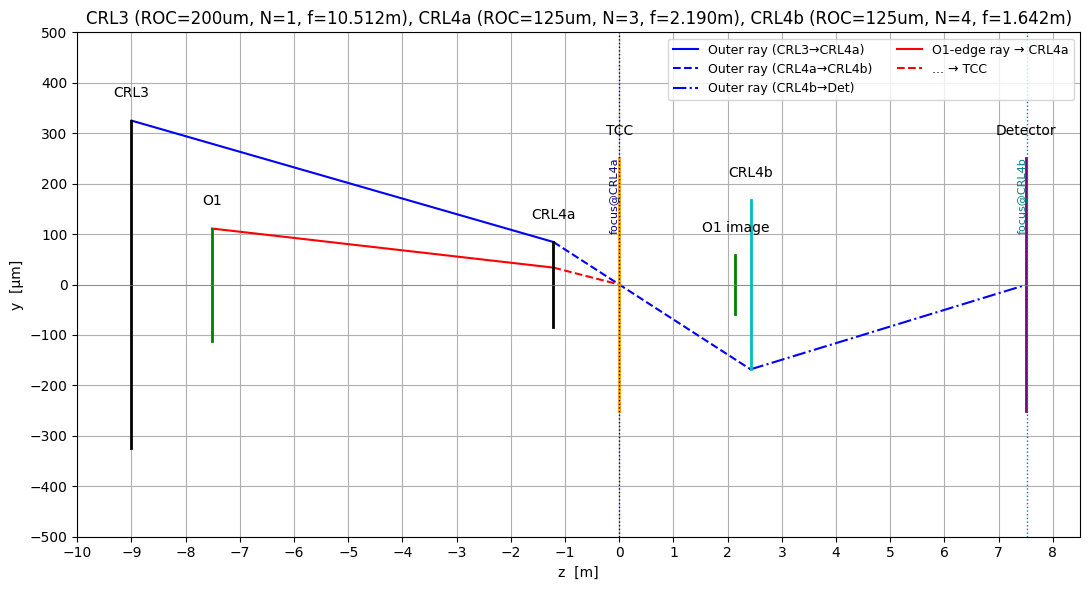

In [1]:
# Ray sketcher for CRL3 → CRL4a → (TCC) → CRL4b → Detector
# Uses thin-lens (ABCD) ray tracing with simple (y, theta) state.

import numpy as np
import matplotlib.pyplot as plt

# ----------------- Inputs (EDIT HERE) -----------------
delta = 9.513092e-6   # diamond at 8766 eV (fixed)

# Beam at CRL3 (parallel rays):
D_crl3 = 650e-6       # beam diameter at CRL3 [m]

# CRL3 (position is fixed at -9 m from TCC):
z_crl3 = -9.0         # [m]
R1, N1 = 200e-6, 1    # ROC [m], number of elements

# CRL4a:
z_crl4a = -1.215       # absolute position [m] (TCC at z=0)
R2, N2  = 125e-6, 3   # ROC [m], number of elements

# CRL4b (position will be set to image(O1 by CRL4a) + 0.20 m)
R3, N3  = 125e-6, 4   # ROC [m], number of elements

# Object O1 (size & position):
Diam_O1 = 222e-6      # [m]
z_O1    = z_crl4a - 6.3  # e.g. 6 m upstream of CRL4a

# Detector:
z_det   = 7.5         # [m]

# ----------------- Helpers -----------------
def f_from_R_N(R, N, delta):
    return R / (2.0 * N * delta)

def free_space(y, th, L):
    return y + L * th, th

def thin_lens(y, th, f):
    return y, th - y / f

# ----------------- Focal lengths -----------------
f1 = f_from_R_N(R1, N1, delta)  # CRL3
f2 = f_from_R_N(R2, N2, delta)  # CRL4a
f3 = f_from_R_N(R3, N3, delta)  # CRL4b

# ----------------- Geometry: O1 image by CRL4a → CRL4b position -----------------
s_o  = z_crl4a - z_O1                          # (>0 if O1 is left of CRL4a)
s_i  = 1.0 / (1.0 / f2 - 1.0 / s_o)
z_O1_img = z_crl4a + s_i
z_crl4b  = z_O1_img + 0.28                     # CRL4b is 20 cm after O1 image

# Magnification & image diameter of O1 (by CRL4a)
M_O1 = s_i / s_o
Diam_O1_img = abs(M_O1) * Diam_O1

# ----------------- TCC -----------------
z_tcc = 0.0

# ----------------- Ray 1: "outer ray" from CRL3 -----------------
y, th = D_crl3 / 2.0, 0.0          # start at top edge, parallel

# CRL3 → CRL4a
y, th = thin_lens(y, th, f1)
y, th = free_space(y, th, z_crl4a - z_crl3)
y_outer_at_crl4a = y

# CRL4a
y, th = thin_lens(y, th, f2)
theta_after_crl4a = th

# Focus of BLUE ray after CRL4a (may be before or after TCC)
if abs(theta_after_crl4a) > 0:
    z_focus_after_crl4a = z_crl4a - y_outer_at_crl4a / theta_after_crl4a
else:
    z_focus_after_crl4a = np.nan  # collimated

# CRL4a → CRL4b
y_before_crl4b, th_before_crl4b = free_space(y, th, z_crl4b - z_crl4a)

# CRL4b
y2, th2 = thin_lens(y_before_crl4b, th_before_crl4b, f3)
theta_after_crl4b = th2

# Focus of BLUE ray after CRL4b (near detector)
if abs(theta_after_crl4b) > 0:
    z_focus_after_crl4b = z_crl4b - y2 / theta_after_crl4b
else:
    z_focus_after_crl4b = np.nan  # collimated

# CRL4b → Detector
y_det, th_det = free_space(y2, th2, z_det - z_crl4b)

# ----------------- Ray 2: "O1-edge ray" aimed to TCC after CRL4a -----------------
y0 = Diam_O1 / 2.0
L3 = z_crl4a - z_O1
L2 = z_tcc - z_crl4a
theta_in_red = - y0 * (1.0 - L2 / f2) / (L3 * (1.0 - L2 / f2) + L2)
y_in_red     = y0 + L3 * theta_in_red                 # at CRL4a (before lens)
dw_over_d    = y_in_red / y_outer_at_crl4a            # requested ratio

# Red polyline (O1→CRL4a→TCC)
def sample_line(z0, y0, z1, theta):
    zz = np.array([z0, z1])
    yy = y0 + (zz - z0) * theta
    return zz, yy

z_red1, y_red1 = sample_line(z_O1, y0, z_crl4a, theta_in_red)
theta_after_red = theta_in_red - y_in_red / f2
z_red2, y_red2 = sample_line(z_crl4a, y_in_red, z_tcc, theta_after_red)  # ends exactly at TCC

# ----------------- Blue polylines for plotting -----------------
y_after_crl3 = D_crl3/2.0
th_after_crl3 = - (D_crl3/2.0) / f1
z_blue1, y_blue1 = sample_line(z_crl3, y_after_crl3, z_crl4a, th_after_crl3)
z_blue2, y_blue2 = sample_line(z_crl4a, y_outer_at_crl4a, z_crl4b, theta_after_crl4a)
z_blue3, y_blue3 = sample_line(z_crl4b, y_before_crl4b, z_det, theta_after_crl4b)

# ----------------- Prints -----------------
print("-------- INPUTS --------")
print(f"CRL3 at z = {z_crl3:.2f} m,  R={R1:.3e} m, N={N1:d}, f1={f1:.3f} m")
print(f"CRL4a at z = {z_crl4a:.3f} m, R={R2:.3e} m, N={N2:d}, f2={f2:.3f} m")
print(f"O1 at z = {z_O1:.2f} m, diameter = {Diam_O1*1e6:.1f} µm")
print(f"O1 image by CRL4a at z = {z_O1_img:.3f} m, diameter = {Diam_O1_img*1e6:.1f} µm")
print(f"CRL4b at z = {z_crl4b:.3f} m (O1 image + 0.20 m), R={R3:.3e} m, N={N3:d}, f3={f3:.3f} m")
print(f"Detector at z = {z_det:.2f} m")

print("\n-------- RESULTS --------")
print(f"Half Angle just after CRL3 (outer ray, toward CRL4a): {abs(th_after_crl3)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4a (outer ray): {abs(theta_after_crl4a)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4b (outer ray): {theta_after_crl4b*1e6:8.2f} µrad")
print(f"d_w/d at CRL4a (height_O1edge / height_outer) = {dw_over_d:.3f}")



# distances to foci
if np.isfinite(z_focus_after_crl4a):
    d_TCC_mm = (z_focus_after_crl4a - z_tcc) * 1e3
    print(f"Blue-ray focus after CRL4a is at z = {z_focus_after_crl4a:.6f} m "
          f"→ distance to TCC: {d_TCC_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4a is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4b):
    d_det_mm = (z_det - z_focus_after_crl4b) * 1e3
    print(f"Blue-ray focus after CRL4b is at z = {z_focus_after_crl4b:.6f} m "
          f"→ distance to detector: {d_det_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4b is collimated (no finite focus).")

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(11, 6))

# Blue ray (outer)
ax.plot(z_blue1, y_blue1*1e6, 'b', label='Outer ray (CRL3→CRL4a)')
ax.plot(z_blue2, y_blue2*1e6, 'b--', label='Outer ray (CRL4a→CRL4b)')
ax.plot(z_blue3, y_blue3*1e6, 'b-.', label='Outer ray (CRL4b→Det)')

# Red ray (O1 edge to TCC via CRL4a)
ax.plot(z_red1, y_red1*1e6, 'r', label='O1-edge ray → CRL4a')
ax.plot(z_red2, y_red2*1e6, 'r--', label='... → TCC')

# Elements as vertical lines
def draw_elem(z, H, label, color='k'):
    ax.plot([z, z], [-H/2*1e6, H/2*1e6], color=color, lw=2)
    ax.text(z, H/2*1e6 + 40, label, ha='center', va='bottom', fontsize=10)

draw_elem(z_crl3, D_crl3, 'CRL3')
draw_elem(z_crl4a, 2*max(abs(y_outer_at_crl4a), abs(y_in_red), 1e-6), 'CRL4a')
draw_elem(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_elem(z_O1, Diam_O1, 'O1', 'g')
draw_elem(z_O1_img, Diam_O1_img, 'O1 image', 'g')
draw_elem(z_crl4b, 2*max(abs(y_before_crl4b), 1e-6), 'CRL4b', 'c')
draw_elem(z_det, 0.5e-3, 'Detector', 'purple')

# Focus markers for the BLUE ray
if np.isfinite(z_focus_after_crl4a):
    ax.axvline(z_focus_after_crl4a, color='navy', ls=':', lw=1)
    ax.text(z_focus_after_crl4a, 100, 'focus@CRL4a', rotation=90, va='bottom', ha='right', color='navy', fontsize=8)
if np.isfinite(z_focus_after_crl4b):
    ax.axvline(z_focus_after_crl4b, color='teal', ls=':', lw=1)
    ax.text(z_focus_after_crl4b, 100, 'focus@CRL4b', rotation=90, va='bottom', ha='right', color='teal', fontsize=8)

# Axes formatting (TCC at 0)
x_min = min(z_crl3, z_O1) - 0.5
x_max = max(z_det, z_O1_img, z_crl4b) + 0.5
yticks = np.arange(-500, 500 + 1, 100)
xticks = np.arange(-10, 10, 1)
ax.set_yticks(yticks)
ax.set_xticks(xticks)
ax.set_xlim(x_min, x_max)
ax.set_xlabel("z  [m]")
ax.set_ylabel("y  [µm]")
ax.axhline(0, color='gray', lw=0.5)
ax.grid(True)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.title(f"CRL3 (ROC={R1*1e6:.0f}um, N={N1}, f={f1:.3f}m), CRL4a (ROC={R2*1e6:.0f}um, N={N2}, f={f2:.3f}m), CRL4b (ROC={R3*1e6:.0f}um, N={N3}, f={f3:.3f}m)")
plt.ylim(-500,500)
plt.xlim(z_crl3-1, z_det+1)
plt.tight_layout()
plt.show()


In [56]:
(300/180)**2

2.777777777777778

-------- INPUTS --------
CRL3 at z = -9.00 m,  R=1.900e-04 m, N=1, f1=9.986 m
CRL4a at z = -1.070 m, R=1.250e-04 m, N=3, f2=2.190 m
O1 at z = -7.37 m, diameter = 222.0 µm
O1 image by CRL4a at z = 2.287 m, diameter = 118.3 µm
CRL4b at z = 2.987 m (O1 image + 0.20 m), R=1.250e-04 m, N=4, f3=1.642 m
Detector at z = 6.60 m

-------- RESULTS --------
Half Angle just after CRL3 (outer ray, toward CRL4a):    32.54 µrad
Half Angle just after CRL4a (outer ray):    63.10 µrad
Half Angle just after CRL4b (outer ray):    52.01 µrad
d_w/d at CRL4a (height_O1edge / height_outer) = 0.414
Blue-ray focus after CRL4a is at z = -0.009502 m → distance to TCC: -9.50 mm
Blue-ray focus after CRL4b is at z = 6.621908 m → distance to detector: -21.91 mm


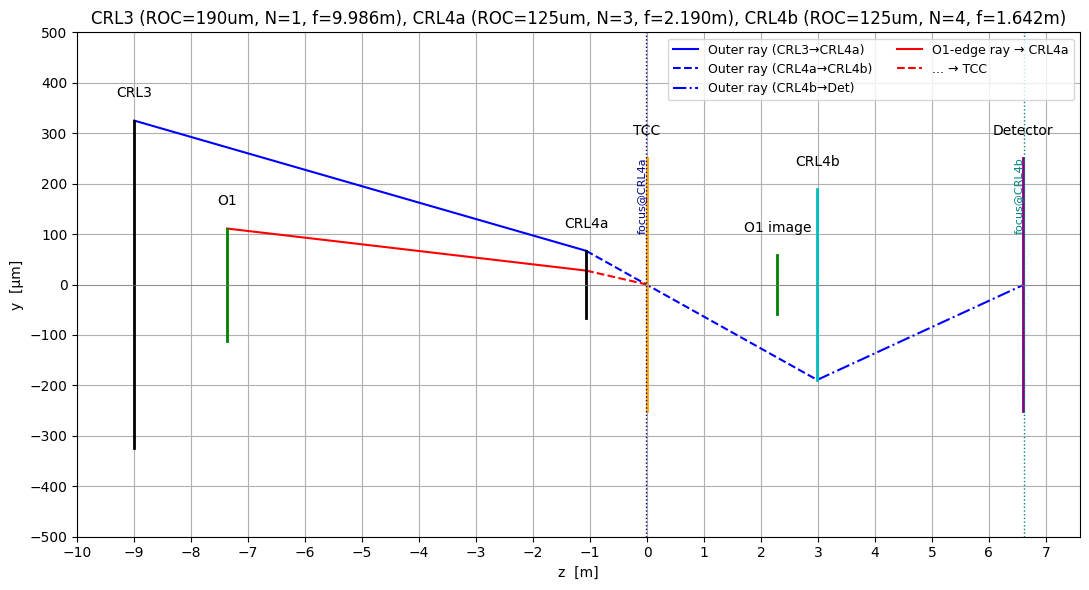

In [44]:
# Ray sketcher for CRL3 → CRL4a → (TCC) → CRL4b → Detector
# Uses thin-lens (ABCD) ray tracing with simple (y, theta) state.

import numpy as np
import matplotlib.pyplot as plt

# ----------------- Inputs (EDIT HERE) -----------------
delta = 9.513092e-6   # diamond at 8766 eV (fixed)

# Beam at CRL3 (parallel rays):
D_crl3 = 650e-6       # beam diameter at CRL3 [m]

# CRL3 (position is fixed at -9 m from TCC):
z_crl3 = -9.0         # [m]
R1, N1 = 190e-6, 1    # ROC [m], number of elements

# CRL4a:
z_crl4a = -1.07       # absolute position [m] (TCC at z=0)
R2, N2  = 125e-6, 3   # ROC [m], number of elements

# CRL4b (position will be set to image(O1 by CRL4a) + 0.20 m)
R3, N3  = 125e-6, 4   # ROC [m], number of elements

# Object O1 (size & position):
Diam_O1 = 222e-6      # [m]
z_O1    = z_crl4a - 6.3  # e.g. 6 m upstream of CRL4a

# Detector:
z_det   = 6.6         # [m]

# ----------------- Helpers -----------------
def f_from_R_N(R, N, delta):
    return R / (2.0 * N * delta)

def free_space(y, th, L):
    return y + L * th, th

def thin_lens(y, th, f):
    return y, th - y / f

# ----------------- Focal lengths -----------------
f1 = f_from_R_N(R1, N1, delta)  # CRL3
f2 = f_from_R_N(R2, N2, delta)  # CRL4a
f3 = f_from_R_N(R3, N3, delta)  # CRL4b

# ----------------- Geometry: O1 image by CRL4a → CRL4b position -----------------
s_o  = z_crl4a - z_O1                          # (>0 if O1 is left of CRL4a)
s_i  = 1.0 / (1.0 / f2 - 1.0 / s_o)
z_O1_img = z_crl4a + s_i
z_crl4b  = z_O1_img + 0.7                     # CRL4b is 20 cm after O1 image

# Magnification & image diameter of O1 (by CRL4a)
M_O1 = s_i / s_o
Diam_O1_img = abs(M_O1) * Diam_O1

# ----------------- TCC -----------------
z_tcc = 0.0

# ----------------- Ray 1: "outer ray" from CRL3 -----------------
y, th = D_crl3 / 2.0, 0.0          # start at top edge, parallel

# CRL3 → CRL4a
y, th = thin_lens(y, th, f1)
y, th = free_space(y, th, z_crl4a - z_crl3)
y_outer_at_crl4a = y

# CRL4a
y, th = thin_lens(y, th, f2)
theta_after_crl4a = th

# Focus of BLUE ray after CRL4a (may be before or after TCC)
if abs(theta_after_crl4a) > 0:
    z_focus_after_crl4a = z_crl4a - y_outer_at_crl4a / theta_after_crl4a
else:
    z_focus_after_crl4a = np.nan  # collimated

# CRL4a → CRL4b
y_before_crl4b, th_before_crl4b = free_space(y, th, z_crl4b - z_crl4a)

# CRL4b
y2, th2 = thin_lens(y_before_crl4b, th_before_crl4b, f3)
theta_after_crl4b = th2

# Focus of BLUE ray after CRL4b (near detector)
if abs(theta_after_crl4b) > 0:
    z_focus_after_crl4b = z_crl4b - y2 / theta_after_crl4b
else:
    z_focus_after_crl4b = np.nan  # collimated

# CRL4b → Detector
y_det, th_det = free_space(y2, th2, z_det - z_crl4b)

# ----------------- Ray 2: "O1-edge ray" aimed to TCC after CRL4a -----------------
y0 = Diam_O1 / 2.0
L3 = z_crl4a - z_O1
L2 = z_tcc - z_crl4a
theta_in_red = - y0 * (1.0 - L2 / f2) / (L3 * (1.0 - L2 / f2) + L2)
y_in_red     = y0 + L3 * theta_in_red                 # at CRL4a (before lens)
dw_over_d    = y_in_red / y_outer_at_crl4a            # requested ratio

# Red polyline (O1→CRL4a→TCC)
def sample_line(z0, y0, z1, theta):
    zz = np.array([z0, z1])
    yy = y0 + (zz - z0) * theta
    return zz, yy

z_red1, y_red1 = sample_line(z_O1, y0, z_crl4a, theta_in_red)
theta_after_red = theta_in_red - y_in_red / f2
z_red2, y_red2 = sample_line(z_crl4a, y_in_red, z_tcc, theta_after_red)  # ends exactly at TCC

# ----------------- Blue polylines for plotting -----------------
y_after_crl3 = D_crl3/2.0
th_after_crl3 = - (D_crl3/2.0) / f1
z_blue1, y_blue1 = sample_line(z_crl3, y_after_crl3, z_crl4a, th_after_crl3)
z_blue2, y_blue2 = sample_line(z_crl4a, y_outer_at_crl4a, z_crl4b, theta_after_crl4a)
z_blue3, y_blue3 = sample_line(z_crl4b, y_before_crl4b, z_det, theta_after_crl4b)

# ----------------- Prints -----------------
print("-------- INPUTS --------")
print(f"CRL3 at z = {z_crl3:.2f} m,  R={R1:.3e} m, N={N1:d}, f1={f1:.3f} m")
print(f"CRL4a at z = {z_crl4a:.3f} m, R={R2:.3e} m, N={N2:d}, f2={f2:.3f} m")
print(f"O1 at z = {z_O1:.2f} m, diameter = {Diam_O1*1e6:.1f} µm")
print(f"O1 image by CRL4a at z = {z_O1_img:.3f} m, diameter = {Diam_O1_img*1e6:.1f} µm")
print(f"CRL4b at z = {z_crl4b:.3f} m (O1 image + 0.20 m), R={R3:.3e} m, N={N3:d}, f3={f3:.3f} m")
print(f"Detector at z = {z_det:.2f} m")

print("\n-------- RESULTS --------")
print(f"Half Angle just after CRL3 (outer ray, toward CRL4a): {abs(th_after_crl3)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4a (outer ray): {abs(theta_after_crl4a)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4b (outer ray): {theta_after_crl4b*1e6:8.2f} µrad")
print(f"d_w/d at CRL4a (height_O1edge / height_outer) = {dw_over_d:.3f}")



# distances to foci
if np.isfinite(z_focus_after_crl4a):
    d_TCC_mm = (z_focus_after_crl4a - z_tcc) * 1e3
    print(f"Blue-ray focus after CRL4a is at z = {z_focus_after_crl4a:.6f} m "
          f"→ distance to TCC: {d_TCC_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4a is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4b):
    d_det_mm = (z_det - z_focus_after_crl4b) * 1e3
    print(f"Blue-ray focus after CRL4b is at z = {z_focus_after_crl4b:.6f} m "
          f"→ distance to detector: {d_det_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4b is collimated (no finite focus).")

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(11, 6))

# Blue ray (outer)
ax.plot(z_blue1, y_blue1*1e6, 'b', label='Outer ray (CRL3→CRL4a)')
ax.plot(z_blue2, y_blue2*1e6, 'b--', label='Outer ray (CRL4a→CRL4b)')
ax.plot(z_blue3, y_blue3*1e6, 'b-.', label='Outer ray (CRL4b→Det)')

# Red ray (O1 edge to TCC via CRL4a)
ax.plot(z_red1, y_red1*1e6, 'r', label='O1-edge ray → CRL4a')
ax.plot(z_red2, y_red2*1e6, 'r--', label='... → TCC')

# Elements as vertical lines
def draw_elem(z, H, label, color='k'):
    ax.plot([z, z], [-H/2*1e6, H/2*1e6], color=color, lw=2)
    ax.text(z, H/2*1e6 + 40, label, ha='center', va='bottom', fontsize=10)

draw_elem(z_crl3, D_crl3, 'CRL3')
draw_elem(z_crl4a, 2*max(abs(y_outer_at_crl4a), abs(y_in_red), 1e-6), 'CRL4a')
draw_elem(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_elem(z_O1, Diam_O1, 'O1', 'g')
draw_elem(z_O1_img, Diam_O1_img, 'O1 image', 'g')
draw_elem(z_crl4b, 2*max(abs(y_before_crl4b), 1e-6), 'CRL4b', 'c')
draw_elem(z_det, 0.5e-3, 'Detector', 'purple')

# Focus markers for the BLUE ray
if np.isfinite(z_focus_after_crl4a):
    ax.axvline(z_focus_after_crl4a, color='navy', ls=':', lw=1)
    ax.text(z_focus_after_crl4a, 100, 'focus@CRL4a', rotation=90, va='bottom', ha='right', color='navy', fontsize=8)
if np.isfinite(z_focus_after_crl4b):
    ax.axvline(z_focus_after_crl4b, color='teal', ls=':', lw=1)
    ax.text(z_focus_after_crl4b, 100, 'focus@CRL4b', rotation=90, va='bottom', ha='right', color='teal', fontsize=8)

# Axes formatting (TCC at 0)
x_min = min(z_crl3, z_O1) - 0.5
x_max = max(z_det, z_O1_img, z_crl4b) + 0.5
yticks = np.arange(-500, 500 + 1, 100)
xticks = np.arange(-10, 10, 1)
ax.set_yticks(yticks)
ax.set_xticks(xticks)
ax.set_xlim(x_min, x_max)
ax.set_xlabel("z  [m]")
ax.set_ylabel("y  [µm]")
ax.axhline(0, color='gray', lw=0.5)
ax.grid(True)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.title(f"CRL3 (ROC={R1*1e6:.0f}um, N={N1}, f={f1:.3f}m), CRL4a (ROC={R2*1e6:.0f}um, N={N2}, f={f2:.3f}m), CRL4b (ROC={R3*1e6:.0f}um, N={N3}, f={f3:.3f}m)")
plt.ylim(-500,500)
plt.xlim(z_crl3-1, z_det+1)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def crl4a_position_from_TCC(R1, N1, R2, N2, Z=9.0, delta=9.513092e-6):
    """
    Given:
      - CRL3:  R1 (apex radius [m]), N1 (number of elements)
      - CRL4a: R2 (apex radius [m]), N2 (number of elements)
      - Z     : desired waist position measured from CRL3 [m]
      - delta : refractive index decrement (dimensionless), fixed

    Returns:
      s_best : CRL4a position measured from CRL3 [m]
      d_TCC  : distance from TCC back to CRL4a [m]  (i.e., d_TCC = Z - s_best)
    """
    # focal lengths f = R / (2 N delta)
    f1 = R1 / (2.0 * N1 * delta)   # CRL3
    f2 = R2 / (2.0 * N2 * delta)   # CRL4a

    # Solve for t = s - f1 from:  Z = f1 + t^2/(t - f2)  →  t^2 - (Z - f1)t + (Z - f1)f2 = 0
    Y = Z - f1
    D = Y * (Y - 4.0 * f2)         # discriminant
    if D < 0:
        raise RuntimeError(f"No real placement for CRL4a (discriminant={D:.3e}). "
                           f"Try different R/N or Z.")
    rt = np.sqrt(D)
    t_candidates = [(Y + rt)/2.0, (Y - rt)/2.0]
    s_candidates = [f1 + t for t in t_candidates]   # positions from CRL3

    # --- selection rule ---
    # keep the solution where the beam has NOT crossed the axis before CRL4a,
    # i.e. place CRL4a BEFORE CRL3's single-lens focus → s < f1;
    # also keep CRL4a between CRL3 and the target → 0 < s < Z.
    s_phys = [s for s in s_candidates if (0 < s < Z) and (s < f1)]
    if not s_phys:
        # If nothing passes, raise with diagnostics
        raise RuntimeError(
            "No solution satisfies 'no crossing before CRL4a'. "
            f"Candidates: {s_candidates}  (f1={f1:.6f}, Z={Z:.6f})"
        )

    s_best = s_phys[0]               # there will be only one under this rule
    d_TCC  = Z - s_best              # distance from TCC back to CRL4a

    # quick verification
    L = f1 - s_best                  # distance from CRL4a to CRL3's focus (>0)
    s_i2 = (f2 * L) / (L + f2)       # image distance of CRL4a
    Z_check = s_best + s_i2
    assert np.allclose(Z_check, Z, rtol=0, atol=1e-9), f"Check failed: {Z_check} vs {Z}"

    return s_best, d_TCC, f1, f2

# ----------------- EDIT YOUR INPUTS HERE -----------------
R1, N1 = 200e-6, 1   # CRL3 geometry
R2, N2 = 125e-6, 3   # CRL4a geometry
Z      = 9.0          # waist position from CRL3 [m]
delta  = 9.513092e-6  # fixed diamond value at 8766 eV

s_from_CRL3, d_from_TCC, f1, f2 = crl4a_position_from_TCC(R1, N1, R2, N2, Z=Z, delta=delta)

print(f"δ (diamond @ 8766 eV) = {delta:.9e}")
print(f"CRL3. ROC = {R1*1e6} um, N = {N1}, f = {f1:.6f} m")
print(f"CRL4. ROC = {R2*1e6} um, N = {N2}, f = {f2:.6f} m")

print(f"CRL4a -{d_from_TCC:.6f} m from TCC")


δ (diamond @ 8766 eV) = 9.513092000e-06
CRL3. ROC = 200.0 um, N = 1, f = 10.511829 m
CRL4. ROC = 125.0 um, N = 3, f = 2.189964 m
CRL4a -1.214430 m from TCC


-------- INPUTS --------
CRL3 at z = -9.00 m,  R=2.000e-04 m, N=1, f1=10.512 m
CRL4a at z = -1.215 m, R=1.250e-04 m, N=3, f2=2.190 m
O1 at z = -7.21 m, diameter = 222.0 µm
O1 image by CRL4a at z = 2.234 m, diameter = 127.6 µm
CRL4b at z = 2.500 m (user-defined), R=1.250e-04 m, N=4, f3=1.642 m
Detector at z = 7.50 m

Initial divergence at CRL3: θ0 = -2.00 µrad

-------- RESULTS --------
Half Angle just after CRL3 (outer ray):   -32.92 µrad
Half Angle just after CRL4a (outer ray):   -64.30 µrad
Half Angle just after CRL4b (outer ray):    39.29 µrad
d_w/d at CRL4a (height_O1edge / height_outer) = 0.505
Blue-ray focus after CRL4a: z = -0.146076 m (distance to TCC: -146.08 mm)
Blue-ray focus after CRL4b: z = 6.830507 m (distance to detector: +669.49 mm)


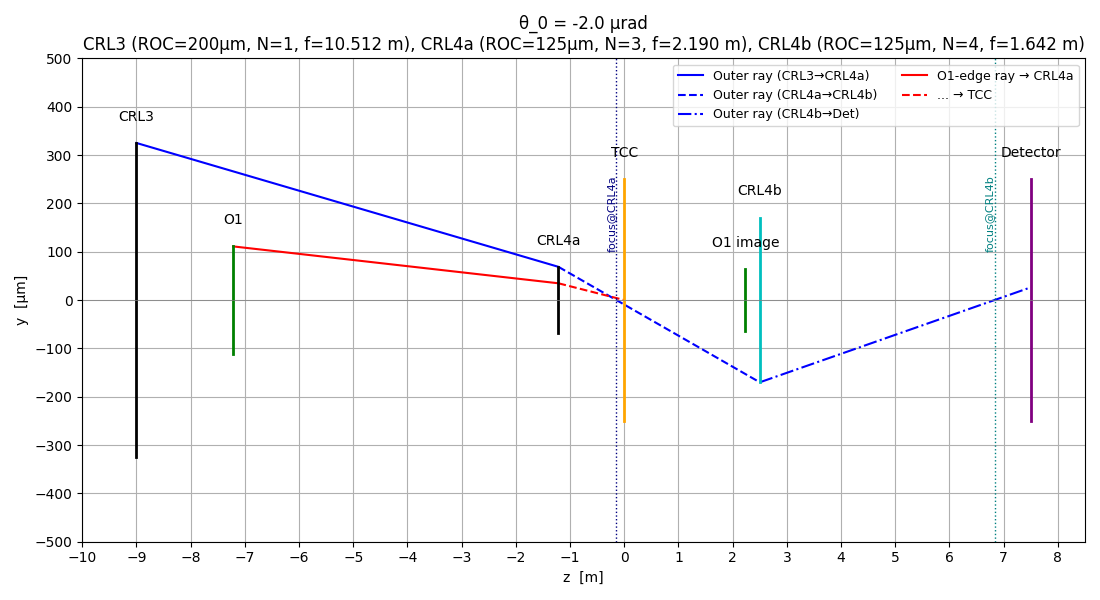

In [18]:
# ======================================================================
# ============ RAY TRACE WITH INITIAL DIVERGENCE AT CRL3 ===============
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------- Inputs (EDIT HERE) -----------------
delta = 9.513092e-6   # diamond at 8766 eV (fixed)

# Beam at CRL3:
D_crl3      = 650e-6       # beam diameter at CRL3 [m]
theta0_urad = -2          # <<< initial beam divergence at CRL3 [µrad] (can be ±)
# Convention: positive θ means upward slope  (y increases with z)

# CRL3 (position is fixed at -9 m from TCC):
z_crl3 = -9.0         # [m]
R1, N1 = 200e-6, 1    # ROC [m], number of elements

# CRL4a:
z_crl4a = -1.215      # absolute position [m] (TCC at z=0)
R2, N2  = 125e-6, 3   # ROC [m], number of elements

# CRL4b (user-defined or auto from O1-image + offset)
R3, N3  = 125e-6, 4   # ROC [m], number of elements
z_crl4b_input = 2.5   # <<< set a value in meters, or None to auto-place
z_crl4b_offset_if_auto = 0.20  # used only if z_crl4b_input is None

# Object O1 (size & position):
Diam_O1 = 222e-6      # [m]
z_O1    = z_crl4a - 6.0  # e.g. 6 m upstream of CRL4a

# Detector:
z_det   = 7.5         # [m]

# ----------------- Helpers -----------------
def f_from_R_N(R, N, delta):
    return R / (2.0 * N * delta)

def free_space(y, th, L):
    return y + L * th, th

def thin_lens(y, th, f):
    return y, th - y / f

def sample_line(z0, y0, z1, theta):
    zz = np.array([z0, z1])
    yy = y0 + (zz - z0) * theta
    return zz, yy

# ----------------- Focal lengths -----------------
f1 = f_from_R_N(R1, N1, delta)  # CRL3
f2 = f_from_R_N(R2, N2, delta)  # CRL4a
f3 = f_from_R_N(R3, N3, delta)  # CRL4b

# ----------------- Geometry: O1 image by CRL4a (info/plot) -----------------
s_o  = z_crl4a - z_O1                          # (>0 if O1 left of CRL4a)
s_i  = 1.0 / (1.0 / f2 - 1.0 / s_o)
z_O1_img = z_crl4a + s_i
M_O1 = s_i / s_o
Diam_O1_img = abs(M_O1) * Diam_O1

# ---- Choose CRL4b position (user-defined OR automatic) ----
if z_crl4b_input is None:
    z_crl4b = z_O1_img + z_crl4b_offset_if_auto
    crl4b_mode = f"auto (O1 image + {z_crl4b_offset_if_auto:.2f} m)"
else:
    z_crl4b = float(z_crl4b_input)
    crl4b_mode = "user-defined"

# ----------------- TCC -----------------
z_tcc = 0.0

# ----------------- Ray 1: "outer ray" from CRL3 with initial divergence ----
theta0 = theta0_urad * 1e-6      # [rad]
y, th  = D_crl3 / 2.0, theta0    # start at top edge, slope = theta0

# CRL3 → CRL4a
y, th = thin_lens(y, th, f1)                             # th = theta0 - y/f1  (with y = D/2)
th_after_crl3 = th
y, th = free_space(y, th, z_crl4a - z_crl3)              # slope unchanged
y_outer_at_crl4a = y

# CRL4a
y, th = thin_lens(y, th, f2)                             # th -= y/f2
theta_after_crl4a = th

# Focus of BLUE ray after CRL4a
if abs(theta_after_crl4a) > 0:
    z_focus_after_crl4a = z_crl4a - y_outer_at_crl4a / theta_after_crl4a
else:
    z_focus_after_crl4a = np.nan  # collimated

# CRL4a → CRL4b
y_before_crl4b, th_before_crl4b = free_space(y, th, z_crl4b - z_crl4a)

# CRL4b
y2, th2 = thin_lens(y_before_crl4b, th_before_crl4b, f3)
theta_after_crl4b = th2

# Focus after CRL4b
if abs(theta_after_crl4b) > 0:
    z_focus_after_crl4b = z_crl4b - y2 / theta_after_crl4b
else:
    z_focus_after_crl4b = np.nan  # collimated

# CRL4b → Detector
y_det, th_det = free_space(y2, th2, z_det - z_crl4b)

# ----------------- Ray 2: "O1-edge ray" aimed to TCC after CRL4a -----------
# (Independent of the incoming divergence from CRL3 — this ray originates at O1)
y0 = Diam_O1 / 2.0
L3 = z_crl4a - z_O1
L2 = z_tcc - z_crl4a
theta_in_red = - y0 * (1.0 - L2 / f2) / (L3 * (1.0 - L2 / f2) + L2)
y_in_red     = y0 + L3 * theta_in_red                 # at CRL4a (before lens)
dw_over_d    = y_in_red / y_outer_at_crl4a            # requested ratio (changes with divergence via y_outer_at_crl4a)

# Red polyline (O1→CRL4a→TCC)
z_red1, y_red1 = sample_line(z_O1, y0, z_crl4a, theta_in_red)
theta_after_red = theta_in_red - y_in_red / f2
z_red2, y_red2 = sample_line(z_crl4a, y_in_red, z_tcc, theta_after_red)  # ends exactly at TCC

# ----------------- Blue polylines for plotting -----------------
# use the true slope just after CRL3, which includes theta0:
z_blue1, y_blue1 = sample_line(z_crl3, D_crl3/2.0, z_crl4a, th_after_crl3)
z_blue2, y_blue2 = sample_line(z_crl4a, y_outer_at_crl4a, z_crl4b, theta_after_crl4a)
z_blue3, y_blue3 = sample_line(z_crl4b, y_before_crl4b, z_det, theta_after_crl4b)

# ----------------- Prints -----------------
print("-------- INPUTS --------")
print(f"CRL3 at z = {z_crl3:.2f} m,  R={R1:.3e} m, N={N1:d}, f1={f1:.3f} m")
print(f"CRL4a at z = {z_crl4a:.3f} m, R={R2:.3e} m, N={N2:d}, f2={f2:.3f} m")
print(f"O1 at z = {z_O1:.2f} m, diameter = {Diam_O1*1e6:.1f} µm")
print(f"O1 image by CRL4a at z = {z_O1_img:.3f} m, diameter = {Diam_O1_img*1e6:.1f} µm")
print(f"CRL4b at z = {z_crl4b:.3f} m ({crl4b_mode}), R={R3:.3e} m, N={N3:d}, f3={f3:.3f} m")
print(f"Detector at z = {z_det:.2f} m")
print(f"\nInitial divergence at CRL3: θ0 = {theta0_urad:.2f} µrad")

print("\n-------- RESULTS --------")
print(f"Half Angle just after CRL3 (outer ray): {th_after_crl3*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4a (outer ray): {theta_after_crl4a*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4b (outer ray): {theta_after_crl4b*1e6:8.2f} µrad")
print(f"d_w/d at CRL4a (height_O1edge / height_outer) = {dw_over_d:.3f}")

# distances to foci
if np.isfinite(z_focus_after_crl4a):
    d_TCC_mm = (z_focus_after_crl4a - z_tcc) * 1e3
    print(f"Blue-ray focus after CRL4a: z = {z_focus_after_crl4a:.6f} m "
          f"(distance to TCC: {d_TCC_mm:+.2f} mm)")
else:
    print("Blue-ray after CRL4a is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4b):
    d_det_mm = (z_det - z_focus_after_crl4b) * 1e3
    print(f"Blue-ray focus after CRL4b: z = {z_focus_after_crl4b:.6f} m "
          f"(distance to detector: {d_det_mm:+.2f} mm)")
else:
    print("Blue-ray after CRL4b is collimated (no finite focus).")

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(11, 6))

# Blue ray (outer)
ax.plot(z_blue1, y_blue1*1e6, 'b', label='Outer ray (CRL3→CRL4a)')
ax.plot(z_blue2, y_blue2*1e6, 'b--', label='Outer ray (CRL4a→CRL4b)')
ax.plot(z_blue3, y_blue3*1e6, 'b-.', label='Outer ray (CRL4b→Det)')

# Red ray (O1 edge to TCC via CRL4a)
ax.plot(z_red1, y_red1*1e6, 'r', label='O1-edge ray → CRL4a')
ax.plot(z_red2, y_red2*1e6, 'r--', label='... → TCC')

# Elements as vertical lines
def draw_elem(z, H, label, color='k'):
    ax.plot([z, z], [-H/2*1e6, H/2*1e6], color=color, lw=2)
    ax.text(z, H/2*1e6 + 40, label, ha='center', va='bottom', fontsize=10)

draw_elem(z_crl3, D_crl3, 'CRL3')
draw_elem(z_crl4a, 2*max(abs(y_outer_at_crl4a), abs(y_in_red), 1e-6), 'CRL4a')
draw_elem(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_elem(z_O1, Diam_O1, 'O1', 'g')
draw_elem(z_O1_img, Diam_O1_img, 'O1 image', 'g')
draw_elem(z_crl4b, 2*max(abs(y_before_crl4b), 1e-6), 'CRL4b', 'c')
draw_elem(z_det, 0.5e-3, 'Detector', 'purple')

# Focus markers for the BLUE ray
if np.isfinite(z_focus_after_crl4a):
    ax.axvline(z_focus_after_crl4a, color='navy', ls=':', lw=1)
    ax.text(z_focus_after_crl4a, 100, 'focus@CRL4a', rotation=90, va='bottom', ha='right', color='navy', fontsize=8)
if np.isfinite(z_focus_after_crl4b):
    ax.axvline(z_focus_after_crl4b, color='teal', ls=':', lw=1)
    ax.text(z_focus_after_crl4b, 100, 'focus@CRL4b', rotation=90, va='bottom', ha='right', color='teal', fontsize=8)

# Axes formatting (TCC at 0)
x_min = min(z_crl3, z_O1) - 0.5
x_max = max(z_det, z_O1_img, z_crl4b) + 0.5
yticks = np.arange(-500, 500 + 1, 100)
xticks = np.arange(-10, 11, 1)
ax.set_yticks(yticks)
ax.set_xticks(xticks)
ax.set_xlim(x_min, x_max)
ax.set_xlabel("z  [m]")
ax.set_ylabel("y  [µm]")
ax.axhline(0, color='gray', lw=0.5)
ax.grid(True)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.title(
    f"θ_0 = {theta0_urad:.1f} µrad\n"
    f"CRL3 (ROC={R1*1e6:.0f}µm, N={N1}, f={f1:.3f} m), "
    f"CRL4a (ROC={R2*1e6:.0f}µm, N={N2}, f={f2:.3f} m), "
    f"CRL4b (ROC={R3*1e6:.0f}µm, N={N3}, f={f3:.3f} m)"
)
plt.ylim(-500, 500)
plt.xlim(z_crl3 - 1, z_det + 1)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1670215/1145469700.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


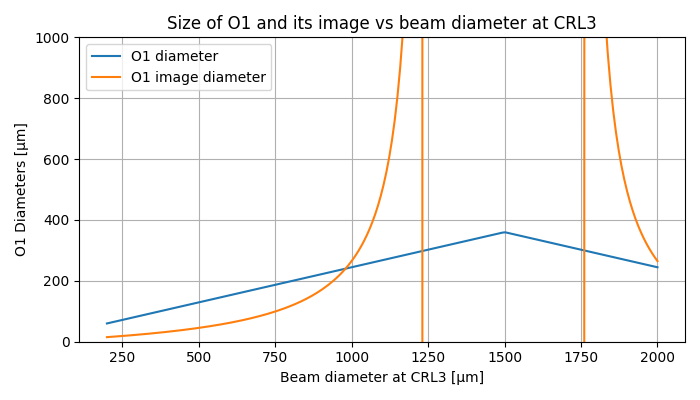

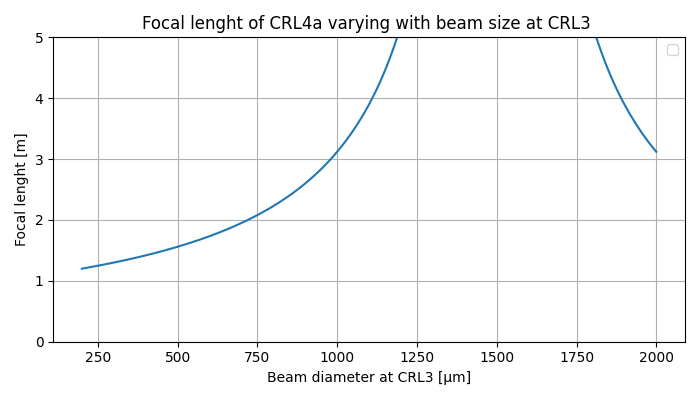

In [13]:
################# PLOT OF THE SIZE OF O1 AND O1 IMAGE AS A FUNCTION OF BEAM DIAMETER AT CRL3 #############
# Fixed parameters
D_crl4a = 200e-6      # 200 µm
X1 = 9                # Distance CRL3 to TCC
X2 = 1.2              # Distance CRL4a to TCC
d_wire_over_d = 0.3   # Beam/wire ratio

# 1. Diameter of O1 and its image vs D_crl3
D_crl3_values = np.linspace(200e-6, 2000e-6, 200)  # 200 µm to 2000 µm
Diam_O1_list = []
Diam_img_O1_list = []
Focal_length_list = []

X3_fixed = 6  # Fixed O1 to CRL4a distance

for D_crl3 in D_crl3_values:
    d_wire = D_crl4a * d_wire_over_d

    f_crl4a = np.abs(D_crl4a / ((D_crl3 - D_crl4a) / (X1 - X2) - D_crl4a / X2))
    X4 = 1 / (1/f_crl4a - 1/X3_fixed)
    M = X4 / X3_fixed

    theta1_in = d_wire / 2 * (1 / X2 - 1 / f_crl4a)
    Diam_O1 = 2 * (d_wire / 2 + theta1_in * X3_fixed)
    Diam_img_O1 = Diam_O1 * M

    Diam_O1_list.append(Diam_O1 * 1e6)
    Diam_img_O1_list.append(Diam_img_O1 * 1e6)
    Focal_length_list.append(f_crl4a)

############## Plot of the size of O1 and image of O1 as a function of the beam diameter at CRL3 ############
plt.figure(figsize=(7,4))
plt.plot(D_crl3_values * 1e6, Diam_O1_list, label="O1 diameter")
plt.plot(D_crl3_values * 1e6, Diam_img_O1_list, label="O1 image diameter")
plt.xlabel("Beam diameter at CRL3 [µm]")
plt.ylabel("O1 Diameters [µm]")
plt.ylim([0,1000])
plt.title("Size of O1 and its image vs beam diameter at CRL3")
plt.grid(True)
plt.legend()
plt.tight_layout()

############## Plot of the focal lenght of CRL4a as a function of the beam diameter at CRL3 ############
plt.figure(figsize=(7,4))
plt.plot(D_crl3_values * 1e6, Focal_length_list)
plt.xlabel("Beam diameter at CRL3 [µm]")
plt.ylabel("Focal lenght [m]")
plt.ylim([0,5])
plt.title("Focal lenght of CRL4a varying with beam size at CRL3 ")
plt.grid(True)
plt.legend()
plt.tight_layout()

In [ ]:
############### PLOT OF THE IMAGE DISTANCE VS THE OBJECT DISTANCE ##########
X3_values = np.linspace(5, 8, 200)
X4_list = []

D_crl3_fixed = 1e-3  # 1000 µm

for X3 in X3_values:
    f_crl4a = np.abs(D_crl4a / ((D_crl3_fixed - D_crl4a) / (X1 - X2) - D_crl4a / X2))
    X4 = 1 / (1/f_crl4a - 1/X3)
    X4_list.append(X4)

plt.figure(figsize=(7,4))
plt.plot(X3_values, X4_list)
plt.xlabel("Distance between O1 and CRL4a [m]")
plt.ylabel("Distance between CRL4a and O1 image [m]")
plt.title("O1 Image distance vs. object distance")
plt.grid(True)
plt.tight_layout()

In [ ]:
############# PLOT OF O1 and O1 image SIZE VS DISTANCE BETWEEN O1 AND CRL4A ############
Diam_O1_list_2 = []
Diam_img_O1_list_2 = []

for X3 in X3_values:
    d_wire = D_crl4a * d_wire_over_d
    f_crl4a = np.abs(D_crl4a / ((D_crl3_fixed - D_crl4a) / (X1 - X2) - D_crl4a / X2))
    X4 = 1 / (1/f_crl4a - 1/X3)
    M = X4 / X3

    theta1_in = d_wire / 2 * (1 / X2 - 1 / f_crl4a)
    Diam_O1 = 2 * (d_wire / 2 + theta1_in * X3)
    Diam_img_O1 = Diam_O1 * M

    Diam_O1_list_2.append(Diam_O1 * 1e6)
    Diam_img_O1_list_2.append(Diam_img_O1 * 1e6)

plt.figure(figsize=(7,4))
plt.plot(X3_values, Diam_O1_list_2, label="O1 diameter")
plt.plot(X3_values, Diam_img_O1_list_2, label="O1 image diameter")
plt.xlabel("Distance between O1 and CRL4a [m]")
plt.ylabel("Diameter of O1 and image of O1 [µm]")
plt.title("Size of O1 and its image vs object distance")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [17]:
R = 125e-6
#f = 2.391
delta = 9.513092e-6

#N = R / (2*f*delta)

#print(N)

N = 3
#N_round = round(N)
f_round = R / (2*N*delta)
print(f"focal lenght = {f_round}m")

focal lenght = 2.189964454599339m


In [4]:
ROC = 125e-6
A = 475e-6
twall= 22e-6
L = twall + A**2 / (4 * ROC)
#L = 1e-3

#twall = L - A**2 / (4*ROC)
print(f"L = {L*1e3} mm")

L = 0.47325 mm


In [4]:
(82-64)/(2.22+1.22)

5.232558139534883

-------- INPUTS --------
CRL3  at z = -9.00 m,  R=2.000e-04 m, N=1, f1=10.512 m
CRL4a at z = -1.215 m, R=1.250e-04 m, N=3, f2=2.190 m
O1 at z = -7.51 m, diameter = 222.0 µm
O1 image by CRL4a at z = 2.142 m, diameter = 118.3 µm
CRL4b at z = 2.422 m (O1 image + 0.28 m), R=1.250e-04 m, N=5, f3=1.314 m
CRL4c at z = 5.80 m, R=1.250e-04 m, N=17, f4=0.386 m
Detector at z = 7.50 m

-------- RESULTS --------
Half Angle just after CRL3 (outer ray, toward CRL4a):    30.92 µrad
Half Angle just after CRL4a (outer ray):                69.41 µrad
Half Angle just after CRL4b (outer ray):                58.55 µrad
Half Angle just after CRL4c (outer ray):               -18.17 µrad
d_w/d at CRL4a (height_O1edge / height_outer) = 0.398
Blue-ray focus after CRL4a is at z = -0.000457 m → distance to TCC: -0.46 mm
Blue-ray focus after CRL4b is at z = 5.293616 m → distance to detector: +2206.38 mm
Blue-ray focus after CRL4c is at z = 7.431924 m → distance to detector: +68.08 mm


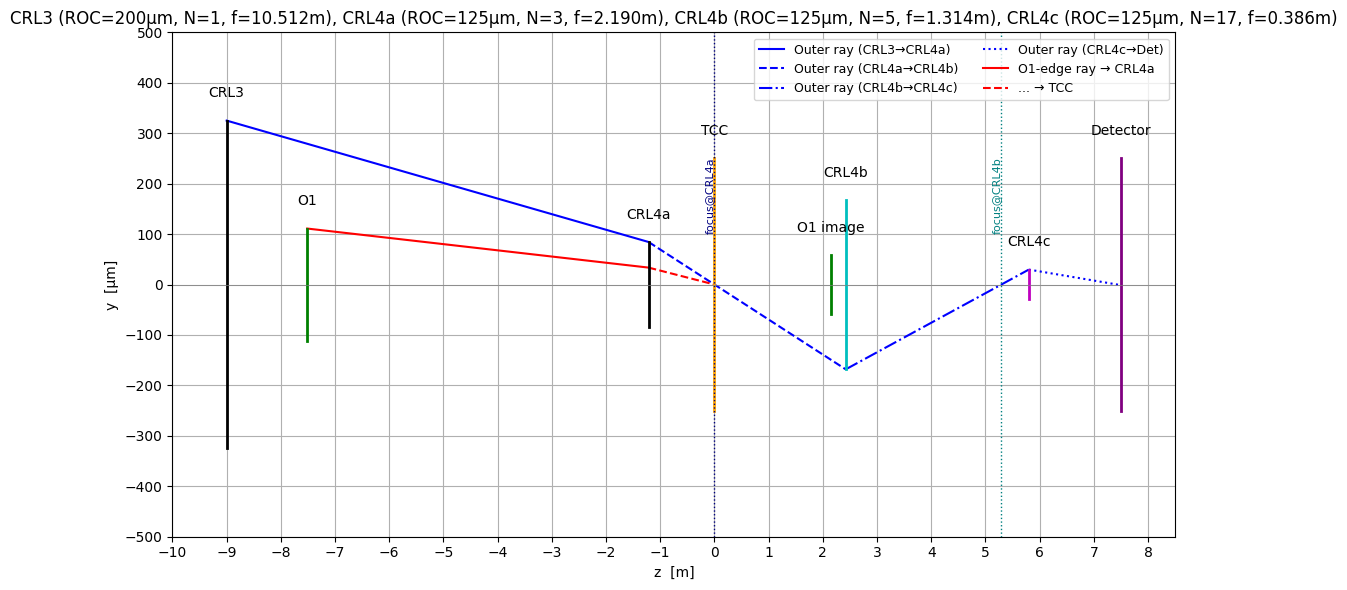

In [1]:
#----- NEW lens design with CRL4c --------------

import numpy as np
import matplotlib.pyplot as plt

# ----------------- Inputs (EDIT HERE) -----------------
delta = 9.513092e-6   # diamond at 8766 eV (fixed)

# Beam at CRL3 (parallel rays):
D_crl3 = 650e-6       # beam diameter at CRL3 [m]

# CRL3 (position is fixed at -9 m from TCC):
z_crl3 = -9.0         # [m]
R1, N1 = 200e-6, 1    # ROC [m], number of elements

# CRL4a:
z_crl4a = -1.215      # absolute position [m] (TCC at z=0)
R2, N2  = 125e-6, 3   # ROC [m], number of elements

# CRL4b (position will be set to image(O1 by CRL4a) + 0.28 m)
R3, N3  = 125e-6, 5   # ROC [m], number of elements  << changed N3 from 4 to 5

# CRL4c
z_crl4c = 5.8         # [m] after TCC
R4, N4  = 125e-6, 17   # ROC [m], number of elements

# Object O1 (size & position):
Diam_O1 = 222e-6      # [m]
z_O1    = z_crl4a - 6.3  # e.g. 6.3 m upstream of CRL4a

# Detector:
z_det   = 7.5         # [m]

# ----------------- Helpers -----------------
def f_from_R_N(R, N, delta):
    return R / (2.0 * N * delta)

def free_space(y, th, L):
    return y + L * th, th

def thin_lens(y, th, f):
    return y, th - y / f

# ----------------- Focal lengths -----------------
f1 = f_from_R_N(R1, N1, delta)  # CRL3
f2 = f_from_R_N(R2, N2, delta)  # CRL4a
f3 = f_from_R_N(R3, N3, delta)  # CRL4b (updated N3=5)
f4 = f_from_R_N(R4, N4, delta)  # CRL4c (new)

# ----------------- Geometry: O1 image by CRL4a → CRL4b position -----------------
s_o  = z_crl4a - z_O1                          # (>0 if O1 is left of CRL4a)
s_i  = 1.0 / (1.0 / f2 - 1.0 / s_o)
z_O1_img = z_crl4a + s_i
z_crl4b  = z_O1_img + 0.28                     # CRL4b is 28 cm after O1 image

# Magnification & image diameter of O1 (by CRL4a)
M_O1 = s_i / s_o
Diam_O1_img = abs(M_O1) * Diam_O1

# ----------------- TCC -----------------
z_tcc = 0.0

# ----------------- Ray 1: "outer ray" from CRL3 -----------------
y, th = D_crl3 / 2.0, 0.0          # start at top edge, parallel

# CRL3 → CRL4a
y, th = thin_lens(y, th, f1)
y, th = free_space(y, th, z_crl4a - z_crl3)
y_outer_at_crl4a = y

# CRL4a
y, th = thin_lens(y, th, f2)
theta_after_crl4a = th

# Focus of BLUE ray after CRL4a (may be before or after TCC)
if abs(theta_after_crl4a) > 0:
    z_focus_after_crl4a = z_crl4a - y_outer_at_crl4a / theta_after_crl4a
else:
    z_focus_after_crl4a = np.nan  # collimated

# CRL4a → CRL4b
y_before_crl4b, th_before_crl4b = free_space(y, th, z_crl4b - z_crl4a)

# CRL4b
y2, th2 = thin_lens(y_before_crl4b, th_before_crl4b, f3)
theta_after_crl4b = th2

# Focus of BLUE ray after CRL4b
if abs(theta_after_crl4b) > 0:
    z_focus_after_crl4b = z_crl4b - y2 / theta_after_crl4b
else:
    z_focus_after_crl4b = np.nan

# CRL4b → CRL4c
y_before_crl4c, th_before_crl4c = free_space(y2, th2, z_crl4c - z_crl4b)

# CRL4c
y3, th3 = thin_lens(y_before_crl4c, th_before_crl4c, f4)
theta_after_crl4c = th3

# Focus of BLUE ray after CRL4c (near detector)
if abs(theta_after_crl4c) > 0:
    z_focus_after_crl4c = z_crl4c - y3 / theta_after_crl4c
else:
    z_focus_after_crl4c = np.nan

# CRL4c → Detector
y_det, th_det = free_space(y3, th3, z_det - z_crl4c)

# ----------------- Ray 2: "O1-edge ray" aimed to TCC after CRL4a -----------------
y0 = Diam_O1 / 2.0
L3 = z_crl4a - z_O1
L2 = z_tcc - z_crl4a
theta_in_red = - y0 * (1.0 - L2 / f2) / (L3 * (1.0 - L2 / f2) + L2)
y_in_red     = y0 + L3 * theta_in_red                 # at CRL4a (before lens)
dw_over_d    = y_in_red / y_outer_at_crl4a            # requested ratio

# Red polyline (O1→CRL4a→TCC)
def sample_line(z0, y0, z1, theta):
    zz = np.array([z0, z1])
    yy = y0 + (zz - z0) * theta
    return zz, yy

z_red1, y_red1 = sample_line(z_O1, y0, z_crl4a, theta_in_red)
theta_after_red = theta_in_red - y_in_red / f2
z_red2, y_red2 = sample_line(z_crl4a, y_in_red, z_tcc, theta_after_red)  # ends exactly at TCC

# ----------------- Blue polylines for plotting -----------------
y_after_crl3 = D_crl3/2.0
th_after_crl3 = - (D_crl3/2.0) / f1
z_blue1, y_blue1 = sample_line(z_crl3, y_after_crl3, z_crl4a, th_after_crl3)
z_blue2, y_blue2 = sample_line(z_crl4a, y_outer_at_crl4a, z_crl4b, theta_after_crl4a)
z_blue3, y_blue3 = sample_line(z_crl4b, y_before_crl4b, z_crl4c, theta_after_crl4b)
z_blue4, y_blue4 = sample_line(z_crl4c, y_before_crl4c, z_det, theta_after_crl4c)

# ----------------- Prints -----------------
print("-------- INPUTS --------")
print(f"CRL3  at z = {z_crl3:.2f} m,  R={R1:.3e} m, N={N1:d}, f1={f1:.3f} m")
print(f"CRL4a at z = {z_crl4a:.3f} m, R={R2:.3e} m, N={N2:d}, f2={f2:.3f} m")
print(f"O1 at z = {z_O1:.2f} m, diameter = {Diam_O1*1e6:.1f} µm")
print(f"O1 image by CRL4a at z = {z_O1_img:.3f} m, diameter = {Diam_O1_img*1e6:.1f} µm")
print(f"CRL4b at z = {z_crl4b:.3f} m (O1 image + 0.28 m), R={R3:.3e} m, N={N3:d}, f3={f3:.3f} m")
print(f"CRL4c at z = {z_crl4c:.2f} m, R={R4:.3e} m, N={N4:d}, f4={f4:.3f} m")
print(f"Detector at z = {z_det:.2f} m")

print("\n-------- RESULTS --------")
print(f"Half Angle just after CRL3 (outer ray, toward CRL4a): {abs(th_after_crl3)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4a (outer ray):             {abs(theta_after_crl4a)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4b (outer ray):             {theta_after_crl4b*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4c (outer ray):             {theta_after_crl4c*1e6:8.2f} µrad")
print(f"d_w/d at CRL4a (height_O1edge / height_outer) = {dw_over_d:.3f}")

# distances to foci
if np.isfinite(z_focus_after_crl4a):
    d_TCC_mm = (z_focus_after_crl4a - z_tcc) * 1e3
    print(f"Blue-ray focus after CRL4a is at z = {z_focus_after_crl4a:.6f} m "
          f"→ distance to TCC: {d_TCC_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4a is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4b):
    d_det_mm_b = (z_det - z_focus_after_crl4b) * 1e3
    print(f"Blue-ray focus after CRL4b is at z = {z_focus_after_crl4b:.6f} m "
          f"→ distance to detector: {d_det_mm_b:+.2f} mm")
else:
    print("Blue-ray after CRL4b is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4c):
    d_det_mm_c = (z_det - z_focus_after_crl4c) * 1e3
    print(f"Blue-ray focus after CRL4c is at z = {z_focus_after_crl4c:.6f} m "
          f"→ distance to detector: {d_det_mm_c:+.2f} mm")
else:
    print("Blue-ray after CRL4c is collimated (no finite focus).")

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(11, 6))

# Blue ray (outer)
ax.plot(z_blue1, y_blue1*1e6, 'b', label='Outer ray (CRL3→CRL4a)')
ax.plot(z_blue2, y_blue2*1e6, 'b--', label='Outer ray (CRL4a→CRL4b)')
ax.plot(z_blue3, y_blue3*1e6, 'b-.', label='Outer ray (CRL4b→CRL4c)')
ax.plot(z_blue4, y_blue4*1e6, 'b:', label='Outer ray (CRL4c→Det)')

# Red ray (O1 edge to TCC via CRL4a)
ax.plot(z_red1, y_red1*1e6, 'r', label='O1-edge ray → CRL4a')
ax.plot(z_red2, y_red2*1e6, 'r--', label='... → TCC')

# Elements as vertical lines
def draw_elem(z, H, label, color='k'):
    ax.plot([z, z], [-H/2*1e6, H/2*1e6], color=color, lw=2)
    ax.text(z, H/2*1e6 + 40, label, ha='center', va='bottom', fontsize=10)

draw_elem(z_crl3, D_crl3, 'CRL3')
draw_elem(z_crl4a, 2*max(abs(y_outer_at_crl4a), abs(y_in_red), 1e-6), 'CRL4a')
draw_elem(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_elem(z_O1, Diam_O1, 'O1', 'g')
draw_elem(z_O1_img, Diam_O1_img, 'O1 image', 'g')
draw_elem(z_crl4b, 2*max(abs(y_before_crl4b), 1e-6), 'CRL4b', 'c')
draw_elem(z_crl4c, 2*max(abs(y_before_crl4c), 1e-6), 'CRL4c', 'm')
draw_elem(z_det, 0.5e-3, 'Detector', 'purple')

# Focus markers for the BLUE ray
if np.isfinite(z_focus_after_crl4a):
    ax.axvline(z_focus_after_crl4a, color='navy', ls=':', lw=1)
    ax.text(z_focus_after_crl4a, 100, 'focus@CRL4a', rotation=90, va='bottom', ha='right', color='navy', fontsize=8)
if np.isfinite(z_focus_after_crl4b):
    ax.axvline(z_focus_after_crl4b, color='teal', ls=':', lw=1)
    ax.text(z_focus_after_crl4b, 100, 'focus@CRL4b', rotation=90, va='bottom', ha='right', color='teal', fontsize=8)
#if np.isfinite(z_focus_after_crl4c):
#    ax.axvline(z_focus_after_crl4c, color='darkmagenta', ls=':', lw=1)
#    ax.text(z_focus_after_crl4c, 100, 'focus@CRL4c', rotation=90, va='bottom', ha='right', color='darkmagenta', fontsize=8)

# Axes formatting (TCC at 0)
x_min = min(z_crl3, z_O1) - 0.5
x_max = max(z_det, z_O1_img, z_crl4b, z_crl4c) + 0.5
yticks = np.arange(-500, 500 + 1, 100)
xticks = np.arange(-10, 10, 1)
ax.set_yticks(yticks)
ax.set_xticks(xticks)
ax.set_xlim(x_min, x_max)
ax.set_xlabel("z  [m]")
ax.set_ylabel("y  [µm]")
ax.axhline(0, color='gray', lw=0.5)
ax.grid(True)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.title(
    f"CRL3 (ROC={R1*1e6:.0f}µm, N={N1}, f={f1:.3f}m), "
    f"CRL4a (ROC={R2*1e6:.0f}µm, N={N2}, f={f2:.3f}m), "
    f"CRL4b (ROC={R3*1e6:.0f}µm, N={N3}, f={f3:.3f}m), "
    f"CRL4c (ROC={R4*1e6:.0f}µm, N={N4}, f={f4:.3f}m)"
)
plt.ylim(-500,500)
plt.xlim(z_crl3-1, z_det+1)
plt.tight_layout()
plt.show()


-------- INPUTS --------
CRL3  [C] at z = -9.00 m,  R=2.000e-04 m, N=1, f1=10.512 m
CRL4a [C] at z = -1.215 m, R=1.250e-04 m, N=3, f2=2.190 m
O1 at z = -7.51 m, diameter = 222.0 µm
O1 image by CRL4a at z = 2.142 m, diameter = 118.3 µm
CRL4b [C] at z = 2.422 m, R=1.250e-04 m, N=5, f3=1.314 m
CRL4c [Be] at z = 5.73 m, R=5.000e-05 m, N=13, f4=0.434 m
Detector at z = 7.50 m

-------- RESULTS --------
Half Angle just after CRL3 (outer ray, toward CRL4a):    30.92 µrad
Half Angle just after CRL4a (outer ray):                69.41 µrad
Half Angle just after CRL4b (outer ray):                58.55 µrad
Half Angle just after CRL4c (outer ray):                -0.37 µrad
d_w/d at CRL4a (height_O1edge / height_outer) = 0.398
Blue-ray focus after CRL4a is at z = -0.000457 m → distance to TCC: -0.46 mm
Blue-ray focus after CRL4b is at z = 5.293616 m → distance to detector: +2206.38 mm
Blue-ray focus after CRL4c is at z = 75.195557 m → distance to detector: -67695.56 mm


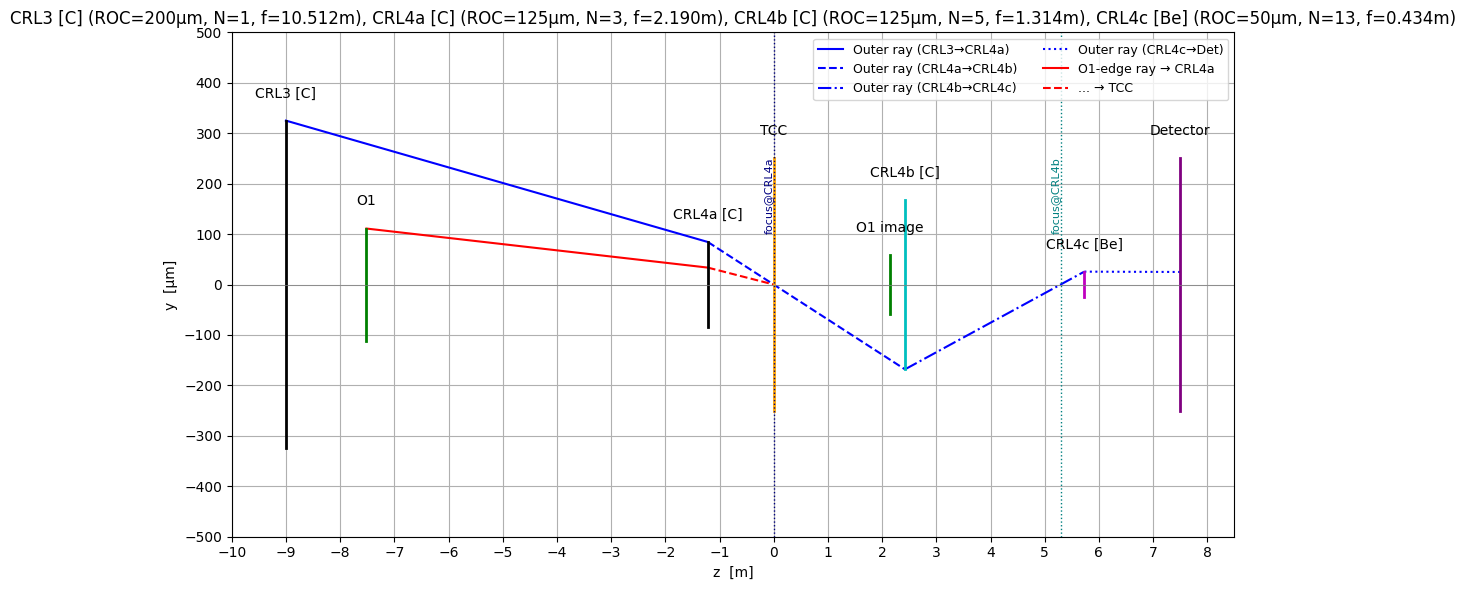

In [3]:
#----- NEW lens design with CRL4c -------------- (materials per lens) -----

import numpy as np
import matplotlib.pyplot as plt

# ----------------- Energy & optical constants (8766 eV) -----------------
# Values consistent with CXRO optical constants at 8.766 keV
DELTA_8766EV = {
    'C':  9.513092e-6,    # diamond
    'Be': 4.43453291e-6,  # beryllium
}
energy_eV = 8766.0  # kept for clarity/future extension

# ----------------- Inputs (EDIT HERE) -----------------
# Beam at CRL3 (parallel rays):
D_crl3 = 650e-6       # beam diameter at CRL3 [m]

# CRL3 (position is fixed at -9 m from TCC):
z_crl3 = -9.0         # [m]
R1, N1 = 200e-6, 1    # ROC [m], number of elements

# CRL4a:
z_crl4a = -1.215      # absolute position [m] (TCC at z=0)
R2, N2  = 125e-6, 3   # ROC [m], number of elements

# CRL4b (position will be set to image(O1 by CRL4a) + 0.28 m)
R3, N3  = 125e-6, 5   # ROC [m], number of elements

# CRL4c:
z_crl4c = 5.73         # [m] after TCC
R4, N4  = 50e-6, 13  # ROC [m], number of elements

# Materials per lens (choose 'C' or 'Be'):
materials = {
    'CRL3':  'C',
    'CRL4a': 'C',
    'CRL4b': 'C',
    'CRL4c': 'Be',
}

# Object O1 (size & position):
Diam_O1 = 222e-6      # [m]
z_O1    = z_crl4a - 6.3  # e.g. 6.3 m upstream of CRL4a

# Detector:
z_det   = 7.5         # [m]

# ----------------- Helpers -----------------
def f_from_R_N(R, N, delta):
    return R / (2.0 * N * delta)

def free_space(y, th, L):
    return y + L * th, th

def thin_lens(y, th, f):
    return y, th - y / f

# ----------------- Focal lengths (material-aware) -----------------
f1 = f_from_R_N(R1, N1, DELTA_8766EV[materials['CRL3']])   # CRL3
f2 = f_from_R_N(R2, N2, DELTA_8766EV[materials['CRL4a']])  # CRL4a
f3 = f_from_R_N(R3, N3, DELTA_8766EV[materials['CRL4b']])  # CRL4b
f4 = f_from_R_N(R4, N4, DELTA_8766EV[materials['CRL4c']])  # CRL4c

# ----------------- Geometry: O1 image by CRL4a → CRL4b position -----------------
s_o  = z_crl4a - z_O1
s_i  = 1.0 / (1.0 / f2 - 1.0 / s_o)
z_O1_img = z_crl4a + s_i
z_crl4b  = z_O1_img + 0.28

M_O1 = s_i / s_o
Diam_O1_img = abs(M_O1) * Diam_O1

# ----------------- TCC -----------------
z_tcc = 0.0

# ----------------- Ray 1: "outer ray" from CRL3 -----------------
y, th = D_crl3 / 2.0, 0.0

# CRL3 → CRL4a
y, th = thin_lens(y, th, f1)
y, th = free_space(y, th, z_crl4a - z_crl3)
y_outer_at_crl4a = y

# CRL4a
y, th = thin_lens(y, th, f2)
theta_after_crl4a = th

# Focus after CRL4a
z_focus_after_crl4a = (z_crl4a - y_outer_at_crl4a / theta_after_crl4a
                       if abs(theta_after_crl4a) > 0 else np.nan)

# CRL4a → CRL4b
y_before_crl4b, th_before_crl4b = free_space(y, th, z_crl4b - z_crl4a)

# CRL4b
y2, th2 = thin_lens(y_before_crl4b, th_before_crl4b, f3)
theta_after_crl4b = th2
z_focus_after_crl4b = (z_crl4b - y2 / theta_after_crl4b
                       if abs(theta_after_crl4b) > 0 else np.nan)

# CRL4b → CRL4c
y_before_crl4c, th_before_crl4c = free_space(y2, th2, z_crl4c - z_crl4b)

# CRL4c
y3, th3 = thin_lens(y_before_crl4c, th_before_crl4c, f4)
theta_after_crl4c = th3
z_focus_after_crl4c = (z_crl4c - y3 / theta_after_crl4c
                       if abs(theta_after_crl4c) > 0 else np.nan)

# CRL4c → Detector
y_det, th_det = free_space(y3, th3, z_det - z_crl4c)

# ----------------- Ray 2: "O1-edge ray" aimed to TCC after CRL4a -----------------
y0 = Diam_O1 / 2.0
L3 = z_crl4a - z_O1
L2 = z_tcc - z_crl4a
theta_in_red = - y0 * (1.0 - L2 / f2) / (L3 * (1.0 - L2 / f2) + L2)
y_in_red     = y0 + L3 * theta_in_red
dw_over_d    = y_in_red / y_outer_at_crl4a

def sample_line(z0, y0, z1, theta):
    zz = np.array([z0, z1])
    yy = y0 + (zz - z0) * theta
    return zz, yy

z_red1, y_red1 = sample_line(z_O1, y0, z_crl4a, theta_in_red)
theta_after_red = theta_in_red - y_in_red / f2
z_red2, y_red2 = sample_line(z_crl4a, y_in_red, z_tcc, theta_after_red)

# ----------------- Blue polylines for plotting -----------------
y_after_crl3 = D_crl3/2.0
th_after_crl3 = - (D_crl3/2.0) / f1
z_blue1, y_blue1 = sample_line(z_crl3, y_after_crl3, z_crl4a, th_after_crl3)
z_blue2, y_blue2 = sample_line(z_crl4a, y_outer_at_crl4a, z_crl4b, theta_after_crl4a)
z_blue3, y_blue3 = sample_line(z_crl4b, y_before_crl4b, z_crl4c, theta_after_crl4b)
z_blue4, y_blue4 = sample_line(z_crl4c, y_before_crl4c, z_det, theta_after_crl4c)

# ----------------- Prints -----------------
print("-------- INPUTS --------")
print(f"CRL3  [{materials['CRL3']}] at z = {z_crl3:.2f} m,  R={R1:.3e} m, N={N1:d}, f1={f1:.3f} m")
print(f"CRL4a [{materials['CRL4a']}] at z = {z_crl4a:.3f} m, R={R2:.3e} m, N={N2:d}, f2={f2:.3f} m")
print(f"O1 at z = {z_O1:.2f} m, diameter = {Diam_O1*1e6:.1f} µm")
print(f"O1 image by CRL4a at z = {z_O1_img:.3f} m, diameter = {Diam_O1_img*1e6:.1f} µm")
print(f"CRL4b [{materials['CRL4b']}] at z = {z_crl4b:.3f} m, R={R3:.3e} m, N={N3:d}, f3={f3:.3f} m")
print(f"CRL4c [{materials['CRL4c']}] at z = {z_crl4c:.2f} m, R={R4:.3e} m, N={N4:d}, f4={f4:.3f} m")
print(f"Detector at z = {z_det:.2f} m")

print("\n-------- RESULTS --------")
print(f"Half Angle just after CRL3 (outer ray, toward CRL4a): {abs(th_after_crl3)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4a (outer ray):             {abs(theta_after_crl4a)*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4b (outer ray):             {theta_after_crl4b*1e6:8.2f} µrad")
print(f"Half Angle just after CRL4c (outer ray):             {theta_after_crl4c*1e6:8.2f} µrad")
print(f"d_w/d at CRL4a (height_O1edge / height_outer) = {dw_over_d:.3f}")

if np.isfinite(z_focus_after_crl4a):
    d_TCC_mm = (z_focus_after_crl4a - z_tcc) * 1e3
    print(f"Blue-ray focus after CRL4a is at z = {z_focus_after_crl4a:.6f} m → distance to TCC: {d_TCC_mm:+.2f} mm")
else:
    print("Blue-ray after CRL4a is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4b):
    d_det_mm_b = (z_det - z_focus_after_crl4b) * 1e3
    print(f"Blue-ray focus after CRL4b is at z = {z_focus_after_crl4b:.6f} m → distance to detector: {d_det_mm_b:+.2f} mm")
else:
    print("Blue-ray after CRL4b is collimated (no finite focus).")

if np.isfinite(z_focus_after_crl4c):
    d_det_mm_c = (z_det - z_focus_after_crl4c) * 1e3
    print(f"Blue-ray focus after CRL4c is at z = {z_focus_after_crl4c:.6f} m → distance to detector: {d_det_mm_c:+.2f} mm")
else:
    print("Blue-ray after CRL4c is collimated (no finite focus).")

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(z_blue1, y_blue1*1e6, 'b', label='Outer ray (CRL3→CRL4a)')
ax.plot(z_blue2, y_blue2*1e6, 'b--', label='Outer ray (CRL4a→CRL4b)')
ax.plot(z_blue3, y_blue3*1e6, 'b-.', label='Outer ray (CRL4b→CRL4c)')
ax.plot(z_blue4, y_blue4*1e6, 'b:', label='Outer ray (CRL4c→Det)')

ax.plot(z_red1, y_red1*1e6, 'r', label='O1-edge ray → CRL4a')
ax.plot(z_red2, y_red2*1e6, 'r--', label='... → TCC')

def draw_elem(z, H, label, color='k'):
    ax.plot([z, z], [-H/2*1e6, H/2*1e6], color=color, lw=2)
    ax.text(z, H/2*1e6 + 40, label, ha='center', va='bottom', fontsize=10)

draw_elem(z_crl3, D_crl3, f"CRL3 [{materials['CRL3']}]",)
draw_elem(z_crl4a, 2*max(abs(y_outer_at_crl4a), abs(y_in_red), 1e-6), f"CRL4a [{materials['CRL4a']}]")
draw_elem(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_elem(z_O1, Diam_O1, 'O1', 'g')
draw_elem(z_O1_img, Diam_O1_img, 'O1 image', 'g')
draw_elem(z_crl4b, 2*max(abs(y_before_crl4b), 1e-6), f"CRL4b [{materials['CRL4b']}]", 'c')
draw_elem(z_crl4c, 2*max(abs(y_before_crl4c), 1e-6), f"CRL4c [{materials['CRL4c']}]", 'm')
draw_elem(z_det, 0.5e-3, 'Detector', 'purple')

if np.isfinite(z_focus_after_crl4a):
    ax.axvline(z_focus_after_crl4a, color='navy', ls=':', lw=1)
    ax.text(z_focus_after_crl4a, 100, 'focus@CRL4a', rotation=90, va='bottom', ha='right', color='navy', fontsize=8)
if np.isfinite(z_focus_after_crl4b):
    ax.axvline(z_focus_after_crl4b, color='teal', ls=':', lw=1)
    ax.text(z_focus_after_crl4b, 100, 'focus@CRL4b', rotation=90, va='bottom', ha='right', color='teal', fontsize=8)

x_min = min(z_crl3, z_O1) - 0.5
x_max = max(z_det, z_O1_img, z_crl4b, z_crl4c) + 0.5
yticks = np.arange(-500, 500 + 1, 100)
xticks = np.arange(-10, 10, 1)
ax.set_yticks(yticks); ax.set_xticks(xticks)
ax.set_xlim(x_min, x_max)
ax.set_xlabel("z  [m]"); ax.set_ylabel("y  [µm]")
ax.axhline(0, color='gray', lw=0.5); ax.grid(True)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.title(
    f"CRL3 [{materials['CRL3']}] (ROC={R1*1e6:.0f}µm, N={N1}, f={f1:.3f}m), "
    f"CRL4a [{materials['CRL4a']}] (ROC={R2*1e6:.0f}µm, N={N2}, f={f2:.3f}m), "
    f"CRL4b [{materials['CRL4b']}] (ROC={R3*1e6:.0f}µm, N={N3}, f={f3:.3f}m), "
    f"CRL4c [{materials['CRL4c']}] (ROC={R4*1e6:.0f}µm, N={N4}, f={f4:.3f}m)"
)
plt.ylim(-500, 500)
plt.xlim(z_crl3 - 1, z_det + 1)
plt.tight_layout()
plt.show()
